# DepthBLIP-2 — Thực nghiệm trên B3DO & SUN3D

**Paper**: [DepthBLIP-2: Leveraging Language to Guide BLIP-2 in Understanding Depth Information (ACCV 2024)](https://openaccess.thecvf.com/content/ACCV2024/papers/Chen_DepthBLIP-2_Leveraging_Language_to_Guide_BLIP-2_in_Understanding_Depth_Information_ACCV_2024_paper.pdf)

## Mục tiêu
- Thực nghiệm DepthBLIP-2 trên **2 tập dữ liệu indoor** mới: **B3DO** và **SUN3D**
- So sánh **2 backbone**: BLIP-2 OPT-2.7B (`method=first`) và InstructBLIP Vicuna-7B (`method=second`)
- Đánh giá và so sánh với kết quả của tác giả trên tập NYU Depth V2

## Thông tin dataset & cấu hình

| Dataset | Loại   | H×W     | depth_scale | max_depth | Metric style |
|---------|--------|---------|-------------|-----------|-------------|
| B3DO    | Indoor | 480×640 | **10000** (0.1mm→m) | 10 m | NYU-style |
| SUN3D   | Indoor | 480×640 | **10000** (0.1mm→m) | 10 m | NYU-style |

## Kết quả tác giả (NYU Depth V2 — tham khảo indoor)

| Method | Fine-tune | Depth bin | abs_rel↓ | log10↓ | rmse↓ | a1↑ | a2↑ | a3↑ |
|--------|-----------|-----------|----------|--------|-------|-----|-----|-----|
| DepthBLIP-2 (Vicuna, **auto bins**) | MLP | auto | **0.363** | **0.153** | **1.132** | **0.401** | **0.707** | **0.898** |
| DepthBLIP-2 (Vicuna, prefix bins)   | MLP | prefix | 0.368 | 0.156 | 1.172 | 0.384 | 0.683 | 0.856 |
| DepthCLIP (baseline)                | 0-shot | prefix | 0.388 | 0.156 | 1.167 | 0.394 | 0.683 | 0.851 |

> **Ghi chú**:
> Training: 16 ảnh, 50 epochs, batch=16, lr=1e-3, AdamW (theo paper).

In [ ]:
# ============================================================
# Cell 1: Import và thiết lập đường dẫn
# ============================================================
import os, sys, re, subprocess, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from pathlib import Path
from PIL import Image

warnings.filterwarnings("ignore")

ROOT   = Path("/media/ssd1tb/Long/depth-blip2")
PYTHON = "/home/hoangtv/anaconda3/envs/dat310/bin/python"
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from blip2_extractor import load_model_and_preprocess  # noqa: F401

# ── Cấu hình B3DO ────────────────────────────────────────────
B3DO_ROOT        = "./datasets/B3DO/"
B3DO_TRAIN_CSV   = "./datasets/B3DO/b3do_train.csv"
B3DO_VAL_CSV     = "./datasets/B3DO/b3do_val.csv"
B3DO_TEST_CSV    = "./datasets/B3DO/b3do_test.csv"
B3DO_DEPTH_SCALE = 10000.0   # 0.1mm → m
B3DO_HEIGHT      = 480
B3DO_WIDTH       = 640
B3DO_MAX_DEPTH   = 10.0

# ── Cấu hình SUN3D ───────────────────────────────────────────
SUN3D_ROOT        = "./datasets/SUN3D/"
SUN3D_TRAIN_CSV   = "./datasets/SUN3D/sun3d_train.csv"
SUN3D_VAL_CSV     = "./datasets/SUN3D/sun3d_val.csv"
SUN3D_TEST_CSV    = "./datasets/SUN3D/sun3d_test.csv"
SUN3D_DEPTH_SCALE = 10000.0   # 0.1mm → m
SUN3D_HEIGHT      = 480
SUN3D_WIDTH       = 640
SUN3D_MAX_DEPTH   = 10.0

# ── Kết quả tham khảo từ paper (NYU Depth V2) ───────────────
PAPER_VICUNA    = dict(Label="Paper (Vicuna, auto_bins)", Dataset="NYU",
                       abs_rel=0.363, log10=0.153, rmse=1.132,
                       a1=0.401, a2=0.707, a3=0.898)
PAPER_DEPTHCLIP = dict(Label="DepthCLIP (baseline)",      Dataset="NYU",
                       abs_rel=0.388, log10=0.156, rmse=1.167,
                       a1=0.394, a2=0.683, a3=0.851)

INDOOR_METRICS = ["abs_diff", "a1", "a2", "a3", "abs_rel", "log10", "rmse"]

print(f"ROOT   = {ROOT}")
print(f"PYTHON = {PYTHON}")
print(f"CUDA   = {torch.cuda.is_available()} (devices: {torch.cuda.device_count()})")


ROOT   = /media/ssd1tb/Long/depth-blip2
PYTHON = /home/hoangtv/anaconda3/envs/dat310/bin/python
CUDA   = True (devices: 2)


---
## 1. Kiểm tra dữ liệu

In [2]:
# ============================================================
# Cell 2: Kiểm tra trạng thái datasets
# ============================================================
def check_dataset(name, root, splits):
    """Kiểm tra dataset CSV và ảnh đầu tiên."""
    print(f"\n{'─'*50}")
    print(f"  Dataset: {name}")
    print(f"{'─'*50}")
    ok = True
    for split, path in splits:
        if not os.path.exists(path):
            print(f"  [MISS] {split:5s}: {path}")
            ok = False
            continue
        df = pd.read_csv(path, header=None, names=["rgb", "depth"])
        first_rgb = os.path.join(root, df.iloc[0]["rgb"])
        status = "✓" if os.path.isfile(first_rgb) else "✗ FILE NOT FOUND"
        print(f"  [{status}] {split:5s}: {len(df):3d} cặp — {path}")
        if not os.path.isfile(first_rgb):
            ok = False
    return ok

b3do_ok = check_dataset("B3DO", B3DO_ROOT, [
    ("train", B3DO_TRAIN_CSV),
    ("val",   B3DO_VAL_CSV),
    ("test",  B3DO_TEST_CSV),
])

sun3d_ok = check_dataset("SUN3D", SUN3D_ROOT, [
    ("train", SUN3D_TRAIN_CSV),
    ("val",   SUN3D_VAL_CSV),
    ("test",  SUN3D_TEST_CSV),
])

print(f"\n{'─'*50}")
print(f"  B3DO  : {'SẴN SÀNG' if b3do_ok else 'THIẾU DỮ LIỆU'}")
print(f"  SUN3D : {'SẴN SÀNG' if sun3d_ok else 'THIẾU DỮ LIỆU'}")


──────────────────────────────────────────────────
  Dataset: B3DO
──────────────────────────────────────────────────
  [✓] train:  42 cặp — ./datasets/B3DO/b3do_train.csv
  [✓] val  :   9 cặp — ./datasets/B3DO/b3do_val.csv
  [✓] test :   9 cặp — ./datasets/B3DO/b3do_test.csv

──────────────────────────────────────────────────
  Dataset: SUN3D
──────────────────────────────────────────────────
  [✓] train:  42 cặp — ./datasets/SUN3D/sun3d_train.csv
  [✓] val  :   9 cặp — ./datasets/SUN3D/sun3d_val.csv
  [✓] test :   9 cặp — ./datasets/SUN3D/sun3d_test.csv

──────────────────────────────────────────────────
  B3DO  : SẴN SÀNG
  SUN3D : SẴN SÀNG


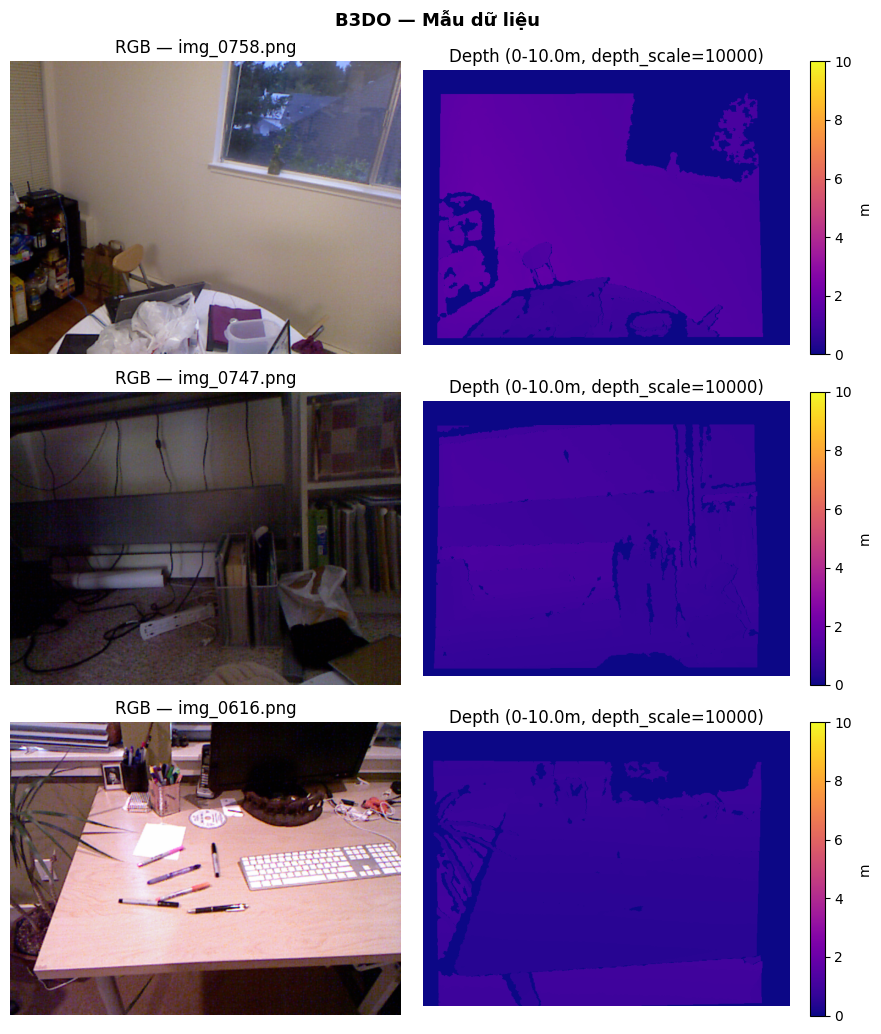

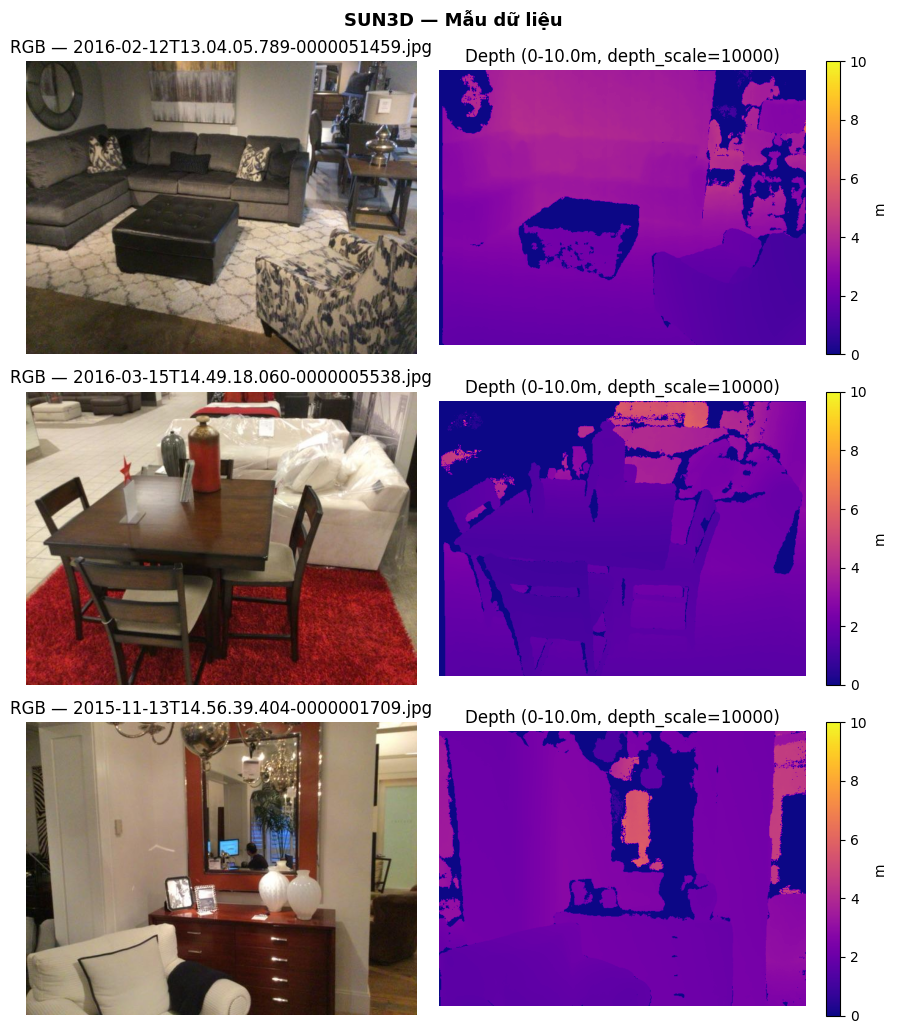

In [3]:
# ============================================================
# Cell 3: Xem mẫu ảnh từ B3DO và SUN3D
# ============================================================
def show_samples(name, root, csv_path, depth_scale, max_depth=10.0, n=3):
    if not os.path.exists(csv_path):
        print(f"[SKIP] {name}: CSV không tồn tại")
        return
    df = pd.read_csv(csv_path, header=None, names=["rgb", "depth"])
    df = df.sample(min(n, len(df)), random_state=1).reset_index(drop=True)

    fig, axes = plt.subplots(len(df), 2, figsize=(9, 3.5 * len(df)))
    if len(df) == 1:
        axes = axes[np.newaxis, :]

    for i, row in df.iterrows():
        rgb_path = os.path.join(root, row["rgb"])
        dep_path = os.path.join(root, row["depth"])
        if not os.path.isfile(rgb_path):
            continue
        rgb = Image.open(rgb_path).convert("RGB")
        dep = np.array(Image.open(dep_path), dtype=np.float32) / depth_scale
        dep = np.clip(dep, 0, max_depth)

        axes[i, 0].imshow(rgb)
        axes[i, 0].set_title(f"RGB — {row['rgb'].split('/')[-1]}")
        im = axes[i, 1].imshow(dep, cmap="plasma", vmin=0, vmax=max_depth)
        plt.colorbar(im, ax=axes[i, 1], fraction=0.046).set_label("m")
        axes[i, 1].set_title(f"Depth (0-{max_depth}m, depth_scale={depth_scale:.0f})")
        for ax in axes[i]: ax.axis("off")

    plt.suptitle(f"{name} — Mẫu dữ liệu", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"log_results/samples_{name.lower()}.png", dpi=100, bbox_inches="tight")
    plt.show()

os.makedirs("log_results", exist_ok=True)
show_samples("B3DO",  B3DO_ROOT,  B3DO_TRAIN_CSV,  B3DO_DEPTH_SCALE,  B3DO_MAX_DEPTH)
show_samples("SUN3D", SUN3D_ROOT, SUN3D_TRAIN_CSV, SUN3D_DEPTH_SCALE, SUN3D_MAX_DEPTH)

---
## 2. Huấn luyện (Training)

Fine-tune **MLP head** của DepthBLIP-2 với `auto_bins=True` — backbone bị đóng băng, chỉ 83K tham số được train.

| Mode | Backbone | Params | Tốc độ |
|------|----------|--------|--------|
| `method=first`  | BLIP-2 OPT-2.7B       | 2.7B total | Nhanh hơn |
| `method=second` | InstructBLIP Vicuna-7B | 7.9B total | Chậm hơn, chính xác hơn |

In [4]:
# ============================================================
# Cell 4: Hàm tiện ích train/test/find_ckpt
# ============================================================
def run_experiment(dataset, data_root, train_file, val_file, test_file,
                   height, width, depth_scale, max_depth,
                   method="second",
                   epochs=50, batch_size=2, train_limit=16, val_limit=8,
                   gpu="0", mode="train"):
    """Chạy train hoặc test qua subprocess, trả về CompletedProcess."""
    base_args = [
        PYTHON, "main.py",
        "--dataset",         dataset,
        "--method",          method,
        "--auto_bins",       "True",
        "--height",          str(height),
        "--width",           str(width),
        "--max_depth",       str(max_depth),
        "--depth_scale",     str(depth_scale),
        "--data_root_path",  data_root,
        "--gpu_num",         gpu,
    ]
    if mode == "train":
        cmd = base_args + [
            "--train",
            "--train_file",    train_file,
            "--val_file",      val_file,
            "--test_file",     val_file,
            "--train_limit",   str(train_limit),
            "--val_limit",     str(val_limit),
            "--batch_size",    str(batch_size),
            "--workers",       "2",
            "--epochs",        str(epochs),
            "--lr",            "0.001",
            "--weight_decay",  "0.01",
            "--train_log_save",
            "--log_result_dir", "./log_results/",
            "--model_save_path", "./checkpoints/",
        ]
    else:
        cmd = base_args + [
            "--test_file",     test_file,
            "--class_name",    "all",
        ]
    return subprocess.run(cmd, cwd=str(ROOT), capture_output=True, text=True)


def find_checkpoint(dataset, method="second", epoch=None, base_dir=None):
    """Tìm checkpoint mới nhất hoặc theo epoch cụ thể."""
    ckpt_root = Path(base_dir) if base_dir else ROOT / "checkpoints"
    base = ckpt_root / f"{method}_{dataset}_bins_True" / "train"
    if not base.exists():
        return None
    runs = sorted(
        (p for p in base.iterdir() if p.is_dir() and p.name.isdigit()),
        key=lambda p: int(p.name)
    )
    if not runs:
        return None
    pths = sorted(runs[-1].glob("model_epoch_*.pth"),
                  key=lambda p: int(p.stem.split("_")[-1]))
    if not pths:
        return None
    if epoch is not None:
        target = next((p for p in pths if int(p.stem.split("_")[-1]) == epoch), None)
        return str(target) if target else None
    return str(pths[-1])


def parse_metrics(stdout, metric_names=INDOOR_METRICS):
    """Trích xuất metrics từ dòng '* * Avg ...' trong stdout."""
    line = next((l for l in stdout.splitlines() if "* * Avg" in l), None)
    if not line:
        return {}
    metrics = {}
    for name in metric_names:
        m = re.search(rf"{re.escape(name)}\s*:\s*([\d.]+)", line)
        if m:
            metrics[name] = float(m.group(1))
    return metrics


print("[OK] Hàm tiện ích đã được định nghĩa")

[OK] Hàm tiện ích đã được định nghĩa


In [5]:
# ============================================================
# Cell 5: Train B3DO — Vicuna-7B (method=second)
# ============================================================
ckpt_b3do_vicuna = find_checkpoint("B3DO", method="second")

if ckpt_b3do_vicuna:
    print(f"[SKIP] Checkpoint B3DO (Vicuna) đã có: {ckpt_b3do_vicuna}")
    print("       Xóa thư mục checkpoints/second_B3DO_bins_True/ để train lại.")
elif not b3do_ok:
    print("[ERROR] Dữ liệu B3DO chưa sẵn sàng. Chạy: python scripts/download_b3do_sample.py")
else:
    print("[START] Bắt đầu train B3DO (Vicuna-7B, 50 epochs, ~30-60 phút) ...")
    res = run_experiment(
        dataset="B3DO", data_root=B3DO_ROOT,
        train_file=B3DO_TRAIN_CSV, val_file=B3DO_VAL_CSV, test_file=B3DO_TEST_CSV,
        height=B3DO_HEIGHT, width=B3DO_WIDTH,
        depth_scale=B3DO_DEPTH_SCALE, max_depth=B3DO_MAX_DEPTH,
        method="second", epochs=50, mode="train"
    )
    # In 50 dòng cuối
    for line in (res.stdout + res.stderr).strip().splitlines()[-50:]:
        print(line)
    if res.returncode == 0:
        ckpt_b3do_vicuna = find_checkpoint("B3DO", method="second")
        print(f"\n[OK] Checkpoint: {ckpt_b3do_vicuna}")
    else:
        print(f"[ERROR] return code: {res.returncode}")

[START] Bắt đầu train B3DO (Vicuna-7B, 50 epochs, ~30-60 phút) ...
Training: epoch 49: 100%|███████████████████| 8/8 [00:07<00:00,  1.13it/s, Abs diff loss=0.42, RMSE loss=0.525, lr=1e-5]

Validating: epoch 49: 100%|██████████████████████████████████████| 4/4 [00:03<00:00,  1.06it/s, abs_diff=0.509, a1=0.35, a2=0.583, a3=0.677, abs_rel=0.469, log10=0.189, rmse=0.606]

Training: epoch 50: 100%|██████████████████| 8/8 [00:06<00:00,  1.16it/s, Abs diff loss=0.421, RMSE loss=0.539, lr=1e-5]

Validating: epoch 50: 100%|██████████████████████████████████████| 4/4 [00:03<00:00,  1.08it/s, abs_diff=0.509, a1=0.35, a2=0.582, a3=0.677, abs_rel=0.469, log10=0.189, rmse=0.606]

[OK] Checkpoint: /media/ssd1tb/Long/depth-blip2/checkpoints/second_B3DO_bins_True/train/0/model_epoch_50.pth


In [6]:
# ============================================================
# Cell 6: Train B3DO — BLIP-2 OPT-2.7B (method=first)
# ============================================================
ckpt_b3do_opt = find_checkpoint("B3DO", method="first")

if ckpt_b3do_opt:
    print(f"[SKIP] Checkpoint B3DO (OPT) đã có: {ckpt_b3do_opt}")
elif not b3do_ok:
    print("[ERROR] Dữ liệu B3DO chưa sẵn sàng.")
else:
    print("[START] Bắt đầu train B3DO (OPT-2.7B, 50 epochs) ...")
    res = run_experiment(
        dataset="B3DO", data_root=B3DO_ROOT,
        train_file=B3DO_TRAIN_CSV, val_file=B3DO_VAL_CSV, test_file=B3DO_TEST_CSV,
        height=B3DO_HEIGHT, width=B3DO_WIDTH,
        depth_scale=B3DO_DEPTH_SCALE, max_depth=B3DO_MAX_DEPTH,
        method="first", epochs=50, mode="train"
    )
    for line in (res.stdout + res.stderr).strip().splitlines()[-50:]:
        print(line)
    if res.returncode == 0:
        ckpt_b3do_opt = find_checkpoint("B3DO", method="first")
        print(f"\n[OK] Checkpoint: {ckpt_b3do_opt}")
    else:
        print(f"[ERROR] return code: {res.returncode}")

[START] Bắt đầu train B3DO (OPT-2.7B, 50 epochs) ...
Training: epoch 49: 100%|██████████████████| 8/8 [00:01<00:00,  5.98it/s, Abs diff loss=0.417, RMSE loss=0.519, lr=1e-5]

Validating: epoch 49: 100%|█████████████████████████████████████| 4/4 [00:00<00:00,  4.80it/s, abs_diff=0.501, a1=0.366, a2=0.592, a3=0.686, abs_rel=0.477, log10=0.186, rmse=0.599]

Training: epoch 50: 100%|██████████████████| 8/8 [00:01<00:00,  6.10it/s, Abs diff loss=0.418, RMSE loss=0.527, lr=1e-5]

Validating: epoch 50: 100%|███████████████████████████████████████| 4/4 [00:00<00:00,  5.66it/s, abs_diff=0.502, a1=0.364, a2=0.591, a3=0.686, abs_rel=0.478, log10=0.186, rmse=0.6]

[OK] Checkpoint: /media/ssd1tb/Long/depth-blip2/checkpoints/first_B3DO_bins_True/train/0/model_epoch_50.pth


In [7]:
# ============================================================
# Cell 7: Train SUN3D — Vicuna-7B (method=second)
# ============================================================
ckpt_sun3d_vicuna = find_checkpoint("SUN3D", method="second")

if ckpt_sun3d_vicuna:
    print(f"[SKIP] Checkpoint SUN3D (Vicuna) đã có: {ckpt_sun3d_vicuna}")
elif not sun3d_ok:
    print("[ERROR] Dữ liệu SUN3D chưa sẵn sàng.")
else:
    print("[START] Bắt đầu train SUN3D (Vicuna-7B, 50 epochs) ...")
    res = run_experiment(
        dataset="SUN3D", data_root=SUN3D_ROOT,
        train_file=SUN3D_TRAIN_CSV, val_file=SUN3D_VAL_CSV, test_file=SUN3D_TEST_CSV,
        height=SUN3D_HEIGHT, width=SUN3D_WIDTH,
        depth_scale=SUN3D_DEPTH_SCALE, max_depth=SUN3D_MAX_DEPTH,
        method="second", epochs=50, mode="train"
    )
    for line in (res.stdout + res.stderr).strip().splitlines()[-50:]:
        print(line)
    if res.returncode == 0:
        ckpt_sun3d_vicuna = find_checkpoint("SUN3D", method="second")
        print(f"\n[OK] Checkpoint: {ckpt_sun3d_vicuna}")
    else:
        print(f"[ERROR] return code: {res.returncode}")

[START] Bắt đầu train SUN3D (Vicuna-7B, 50 epochs) ...
Training: epoch 49: 100%|██████████████████| 8/8 [00:07<00:00,  1.14it/s, Abs diff loss=0.616, RMSE loss=0.822, lr=1e-5]

Validating: epoch 49: 100%|████████████████████████████████████████| 4/4 [00:03<00:00,  1.11it/s, abs_diff=0.63, a1=0.53, a2=0.796, a3=0.928, abs_rel=0.27, log10=0.119, rmse=0.881]

Training: epoch 50: 100%|██████████████████| 8/8 [00:07<00:00,  1.14it/s, Abs diff loss=0.608, RMSE loss=0.815, lr=1e-5]

Validating: epoch 50: 100%|████████████████████████████████████████| 4/4 [00:03<00:00,  1.12it/s, abs_diff=0.63, a1=0.53, a2=0.797, a3=0.928, abs_rel=0.27, log10=0.119, rmse=0.881]

[OK] Checkpoint: /media/ssd1tb/Long/depth-blip2/checkpoints/second_SUN3D_bins_True/train/0/model_epoch_50.pth


In [8]:
# ============================================================
# Cell 8: Train SUN3D — BLIP-2 OPT-2.7B (method=first)
# ============================================================
ckpt_sun3d_opt = find_checkpoint("SUN3D", method="first")

if ckpt_sun3d_opt:
    print(f"[SKIP] Checkpoint SUN3D (OPT) đã có: {ckpt_sun3d_opt}")
elif not sun3d_ok:
    print("[ERROR] Dữ liệu SUN3D chưa sẵn sàng.")
else:
    print("[START] Bắt đầu train SUN3D (OPT-2.7B, 50 epochs) ...")
    res = run_experiment(
        dataset="SUN3D", data_root=SUN3D_ROOT,
        train_file=SUN3D_TRAIN_CSV, val_file=SUN3D_VAL_CSV, test_file=SUN3D_TEST_CSV,
        height=SUN3D_HEIGHT, width=SUN3D_WIDTH,
        depth_scale=SUN3D_DEPTH_SCALE, max_depth=SUN3D_MAX_DEPTH,
        method="first", epochs=50, mode="train"
    )
    for line in (res.stdout + res.stderr).strip().splitlines()[-50:]:
        print(line)
    if res.returncode == 0:
        ckpt_sun3d_opt = find_checkpoint("SUN3D", method="first")
        print(f"\n[OK] Checkpoint: {ckpt_sun3d_opt}")
    else:
        print(f"[ERROR] return code: {res.returncode}")

[START] Bắt đầu train SUN3D (OPT-2.7B, 50 epochs) ...
Training: epoch 49: 100%|██████████████████| 8/8 [00:01<00:00,  6.00it/s, Abs diff loss=0.618, RMSE loss=0.819, lr=1e-5]

Validating: epoch 49: 100%|█████████████████████████████████████| 4/4 [00:00<00:00,  5.10it/s, abs_diff=0.631, a1=0.521, a2=0.801, a3=0.929, abs_rel=0.274, log10=0.119, rmse=0.876]

Training: epoch 50: 100%|███████████████████| 8/8 [00:01<00:00,  6.37it/s, Abs diff loss=0.612, RMSE loss=0.82, lr=1e-5]

Validating: epoch 50: 100%|██████████████████████████████████████| 4/4 [00:00<00:00,  5.49it/s, abs_diff=0.631, a1=0.523, a2=0.801, a3=0.93, abs_rel=0.274, log10=0.119, rmse=0.875]

[OK] Checkpoint: /media/ssd1tb/Long/depth-blip2/checkpoints/first_SUN3D_bins_True/train/0/model_epoch_50.pth


---
## 3. Đánh giá (Testing)

In [9]:
# ============================================================
# Cell 9: Hàm test và thu thập kết quả
# ============================================================
def run_test(dataset, data_root, test_file, height, width,
             depth_scale, max_depth, model_path, method="second", gpu="0"):
    """Chạy test và trả về dict metrics."""
    cmd = [
        PYTHON, "main.py",
        "--dataset",         dataset,
        "--method",          method,
        "--auto_bins",       "True",
        "--height",          str(height),
        "--width",           str(width),
        "--max_depth",       str(max_depth),
        "--depth_scale",     str(depth_scale),
        "--data_root_path",  data_root,
        "--test_file",       test_file,
        "--class_name",      "all",
        "--gpu_num",         gpu,
        "--model_load_path", model_path,
    ]
    print(f"  Testing {dataset} ({method}) ...")
    res = subprocess.run(cmd, cwd=str(ROOT), capture_output=True, text=True)

    for line in res.stdout.splitlines():
        if "Avg" in line or "finish" in line:
            print(f"  {line.strip()}")
    if res.returncode != 0:
        print(f"  [ERROR] {res.stderr[-300:]}")
        return {}
    return parse_metrics(res.stdout)


print("[OK] Hàm run_test đã sẵn sàng")

[OK] Hàm run_test đã sẵn sàng


In [10]:
# ============================================================
# Cell 10: Chạy test tất cả 4 cấu hình
# ============================================================
results = {}   

# Cập nhật checkpoints
ckpt_b3do_vicuna  = find_checkpoint("B3DO",  method="second")
ckpt_b3do_opt     = find_checkpoint("B3DO",  method="first")
ckpt_sun3d_vicuna = find_checkpoint("SUN3D", method="second")
ckpt_sun3d_opt    = find_checkpoint("SUN3D", method="first")

configs = [
    ("B3DO",  "second", B3DO_ROOT,  B3DO_TEST_CSV,  B3DO_HEIGHT,  B3DO_WIDTH,
     B3DO_DEPTH_SCALE,  B3DO_MAX_DEPTH,  ckpt_b3do_vicuna),
    ("B3DO",  "first",  B3DO_ROOT,  B3DO_TEST_CSV,  B3DO_HEIGHT,  B3DO_WIDTH,
     B3DO_DEPTH_SCALE,  B3DO_MAX_DEPTH,  ckpt_b3do_opt),
    ("SUN3D", "second", SUN3D_ROOT, SUN3D_TEST_CSV, SUN3D_HEIGHT, SUN3D_WIDTH,
     SUN3D_DEPTH_SCALE, SUN3D_MAX_DEPTH, ckpt_sun3d_vicuna),
    ("SUN3D", "first",  SUN3D_ROOT, SUN3D_TEST_CSV, SUN3D_HEIGHT, SUN3D_WIDTH,
     SUN3D_DEPTH_SCALE, SUN3D_MAX_DEPTH, ckpt_sun3d_opt),
]

for (dataset, method, data_root, test_file,
     height, width, depth_scale, max_depth, ckpt) in configs:
    key = f"{dataset}_{method}"
    if ckpt is None:
        print(f"[SKIP] {key}: chưa có checkpoint")
        continue
    m = run_test(dataset, data_root, test_file, height, width,
                 depth_scale, max_depth, ckpt, method)
    if m:
        results[key] = m

print(f"\n[OK] Đã test {len(results)}/4 cấu hình: {list(results.keys())}")

  Testing B3DO (second) ...
  * * Avg abs_diff : 0.436, a1 : 0.322, a2 : 0.596, a3 : 0.772, abs_rel : 0.504, log10 : 0.183, rmse : 0.581
  B3DO validation finish
  Testing B3DO (first) ...
  * * Avg abs_diff : 0.447, a1 : 0.320, a2 : 0.584, a3 : 0.756, abs_rel : 0.530, log10 : 0.187, rmse : 0.586
  B3DO validation finish
  Testing SUN3D (second) ...
  * * Avg abs_diff : 0.566, a1 : 0.516, a2 : 0.853, a3 : 0.962, abs_rel : 0.266, log10 : 0.110, rmse : 0.743
  SUN3D validation finish
  Testing SUN3D (first) ...
  * * Avg abs_diff : 0.570, a1 : 0.513, a2 : 0.848, a3 : 0.960, abs_rel : 0.272, log10 : 0.111, rmse : 0.743
  SUN3D validation finish

[OK] Đã test 4/4 cấu hình: ['B3DO_second', 'B3DO_first', 'SUN3D_second', 'SUN3D_first']


---
## 4. So sánh kết quả & Báo cáo

In [11]:
# ============================================================
# Cell 11: Bảng so sánh kết quả
# ============================================================
CMP_COLS = ["abs_rel", "log10", "rmse", "a1", "a2", "a3"]

rows = []

# Kết quả paper
rows.append({"Phương pháp": "DepthCLIP (baseline)",   "Dataset": "NYU (Paper)",
             **{k: PAPER_DEPTHCLIP[k] for k in CMP_COLS}})
rows.append({"Phương pháp": "DepthBLIP-2 (Vicuna, auto)", "Dataset": "NYU (Paper)",
             **{k: PAPER_VICUNA[k] for k in CMP_COLS}})

# Kết quả thực nghiệm của chúng ta
METHOD_LABEL = {"second": "Vicuna-7B", "first": "OPT-2.7B"}
for (dataset, method, *_) in configs:
    key = f"{dataset}_{method}"
    if key not in results:
        continue
    rows.append({
        "Phương pháp": f"DepthBLIP-2 ({METHOD_LABEL[method]})",
        "Dataset": f"{dataset} (Ours)",
        **{k: results[key].get(k, float("nan")) for k in CMP_COLS},
    })

df_cmp = pd.DataFrame(rows).set_index(["Phương pháp", "Dataset"])

print("=" * 90)
print("   BẢNG SO SÁNH KẾT QUẢ — Indoor Monocular Depth Estimation")
print("=" * 90)
print(df_cmp[CMP_COLS].to_string(float_format="%.3f"))
print("=" * 90)
print("  ↓ thấp hơn = tốt hơn: abs_rel, log10, rmse")
print("  ↑ cao hơn  = tốt hơn: a1, a2, a3")

   BẢNG SO SÁNH KẾT QUẢ — Indoor Monocular Depth Estimation
                                         abs_rel  log10  rmse    a1    a2    a3
Phương pháp                Dataset                                             
DepthCLIP (baseline)       NYU (Paper)     0.388  0.156 1.167 0.394 0.683 0.851
DepthBLIP-2 (Vicuna, auto) NYU (Paper)     0.363  0.153 1.132 0.401 0.707 0.898
DepthBLIP-2 (Vicuna-7B)    B3DO (Ours)     0.504  0.183 0.581 0.322 0.596 0.772
DepthBLIP-2 (OPT-2.7B)     B3DO (Ours)     0.530  0.187 0.586 0.320 0.584 0.756
DepthBLIP-2 (Vicuna-7B)    SUN3D (Ours)    0.266  0.110 0.743 0.516 0.853 0.962
DepthBLIP-2 (OPT-2.7B)     SUN3D (Ours)    0.272  0.111 0.743 0.513 0.848 0.960
  ↓ thấp hơn = tốt hơn: abs_rel, log10, rmse
  ↑ cao hơn  = tốt hơn: a1, a2, a3


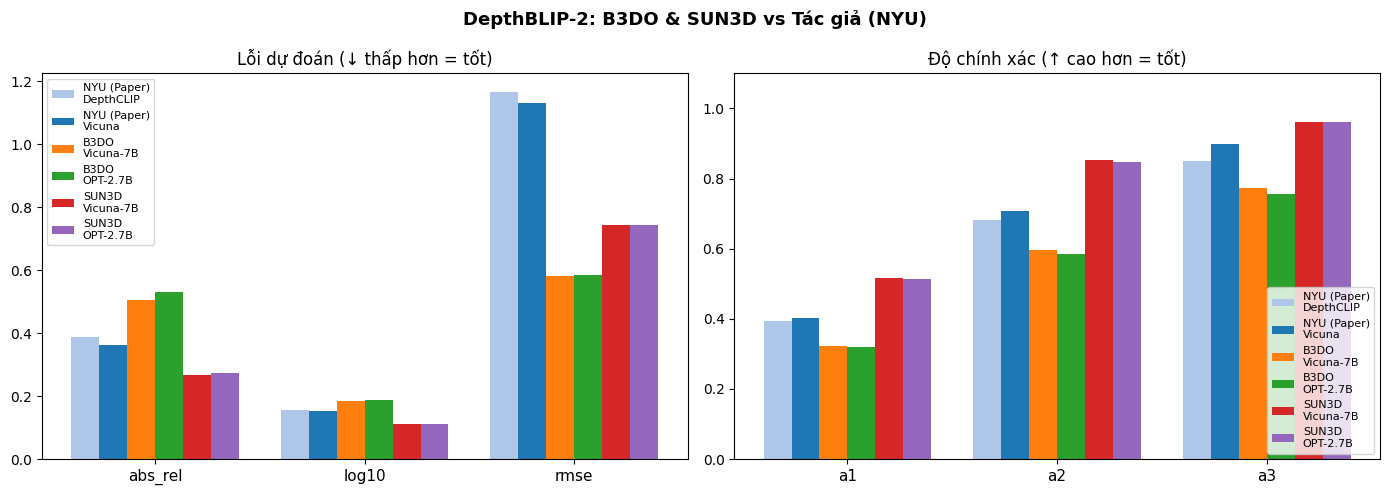

[OK] Đã lưu log_results/comparison_chart.png


In [12]:
# ============================================================
# Cell 12: Biểu đồ so sánh
# ============================================================
if not results:
    print("[SKIP] Chưa có kết quả test. Chạy cell Train và Test trước.")
else:
    COLORS = {
        "NYU (Paper) — DepthCLIP":     "#aec7e8",
        "NYU (Paper) — Vicuna (auto)": "#1f77b4",
    }
    PALETTE = ["#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

    all_rows = []
    all_rows.append({"label": "NYU (Paper)\nDepthCLIP",
                     **{k: PAPER_DEPTHCLIP[k] for k in CMP_COLS}})
    all_rows.append({"label": "NYU (Paper)\nVicuna",
                     **{k: PAPER_VICUNA[k] for k in CMP_COLS}})
    for i, (dataset, method, *_) in enumerate(configs):
        key = f"{dataset}_{method}"
        if key not in results:
            continue
        all_rows.append({
            "label": f"{dataset}\n{METHOD_LABEL[method]}",
            **{k: results[key].get(k, 0) for k in CMP_COLS},
        })

    labels   = [r["label"] for r in all_rows]
    n        = len(labels)
    colors   = ["#aec7e8", "#1f77b4"] + PALETTE[:n-2]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Error metrics (thấp hơn = tốt)
    err_cols = ["abs_rel", "log10", "rmse"]
    x = np.arange(len(err_cols))
    w = 0.8 / n
    for i, (row, label, color) in enumerate(zip(all_rows, labels, colors)):
        vals = [row[c] for c in err_cols]
        axes[0].bar(x + (i - n/2 + 0.5)*w, vals, w, label=label, color=color)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(err_cols, fontsize=11)
    axes[0].set_title("Lỗi dự đoán (↓ thấp hơn = tốt)", fontsize=12)
    axes[0].legend(fontsize=8, loc="upper left")

    # Accuracy metrics (cao hơn = tốt)
    acc_cols = ["a1", "a2", "a3"]
    x = np.arange(len(acc_cols))
    for i, (row, label, color) in enumerate(zip(all_rows, labels, colors)):
        vals = [row[c] for c in acc_cols]
        axes[1].bar(x + (i - n/2 + 0.5)*w, vals, w, label=label, color=color)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(acc_cols, fontsize=11)
    axes[1].set_title("Độ chính xác (↑ cao hơn = tốt)", fontsize=12)
    axes[1].set_ylim(0, 1.1)
    axes[1].legend(fontsize=8, loc="lower right")

    plt.suptitle("DepthBLIP-2: B3DO & SUN3D vs Tác giả (NYU)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    os.makedirs("log_results", exist_ok=True)
    plt.savefig("log_results/comparison_chart.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("[OK] Đã lưu log_results/comparison_chart.png")

---
## 5. Trực quan hóa kết quả dự đoán

Load model


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  5.08it/s]


End loading model
Start OmegaConf
End OmegaConf
preprocess_cfg: {'vis_processor': {'train': {'name': 'blip2_image_train', 'image_size': 224}, 'eval': {'name': 'blip_image_eval', 'image_size': 224}}, 'text_processor': {'train': {'name': 'blip_caption'}, 'eval': {'name': 'blip_caption'}}}
Start loading visual and textual model
{'builder_name_mapping': {}, 'task_name_mapping': {}, 'processor_name_mapping': {'blip_caption': <class 'processors.blip_processors.BlipCaptionProcessor'>, 'blip_question': <class 'processors.blip_processors.BlipQuestionProcessor'>, 'blip_image_train': <class 'processors.blip_processors.BlipImageTrainProcessor'>, 'blip_image_eval': <class 'processors.blip_processors.BlipImageEvalProcessor'>, 'blip2_image_train': <class 'processors.blip_processors.Blip2ImageTrainProcessor'>, 'clip_image_train': <class 'processors.clip_processors.ClipImageTrainProcessor'>, 'clip_image_eval': <class 'processors.clip_processors.ClipImageEvalProcessor'>}, 'model_name_mapping': {'depth_b

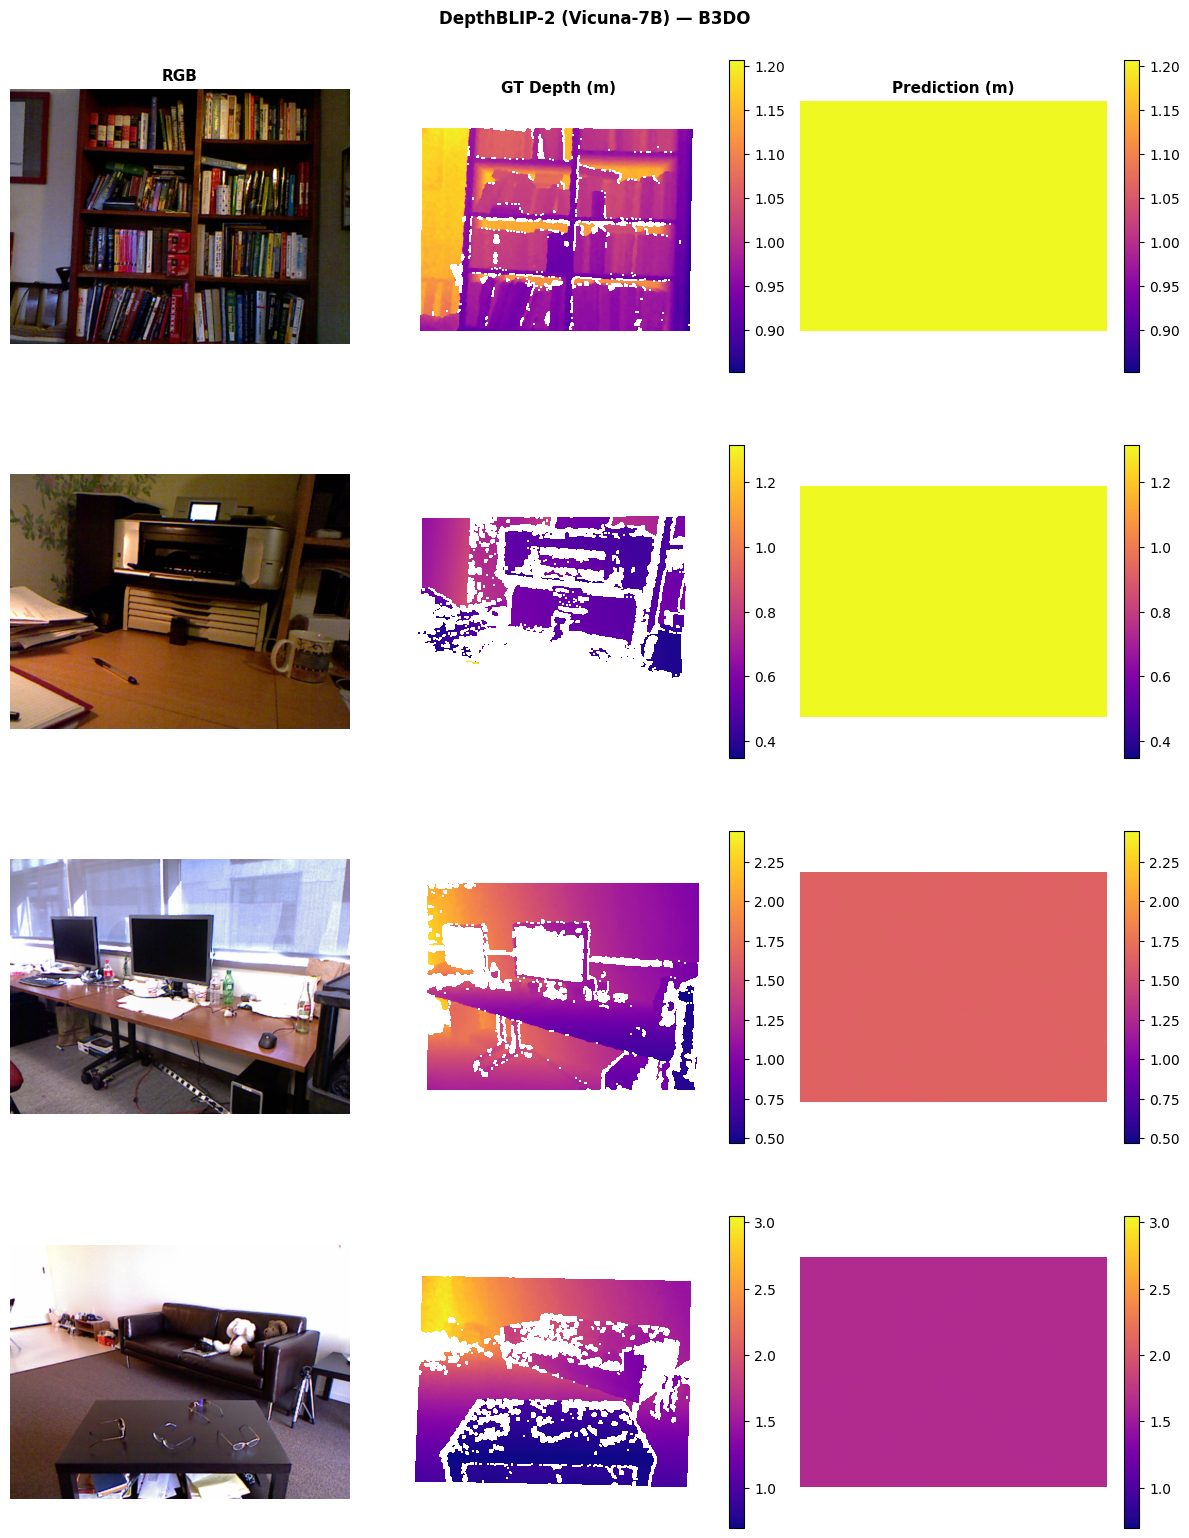

[Saved] log_results/viz/pred_b3do_second.png
Load model
End loading model
Start OmegaConf
End OmegaConf
preprocess_cfg: {'vis_processor': {'train': {'name': 'blip_image_train', 'image_size': 224}, 'eval': {'name': 'blip_image_eval', 'image_size': 224}}, 'text_processor': {'train': {'name': 'blip_caption'}, 'eval': {'name': 'blip_caption'}}}
Start loading visual and textual model
{'builder_name_mapping': {}, 'task_name_mapping': {}, 'processor_name_mapping': {'blip_caption': <class 'processors.blip_processors.BlipCaptionProcessor'>, 'blip_question': <class 'processors.blip_processors.BlipQuestionProcessor'>, 'blip_image_train': <class 'processors.blip_processors.BlipImageTrainProcessor'>, 'blip_image_eval': <class 'processors.blip_processors.BlipImageEvalProcessor'>, 'blip2_image_train': <class 'processors.blip_processors.Blip2ImageTrainProcessor'>, 'clip_image_train': <class 'processors.clip_processors.ClipImageTrainProcessor'>, 'clip_image_eval': <class 'processors.clip_processors.Cli

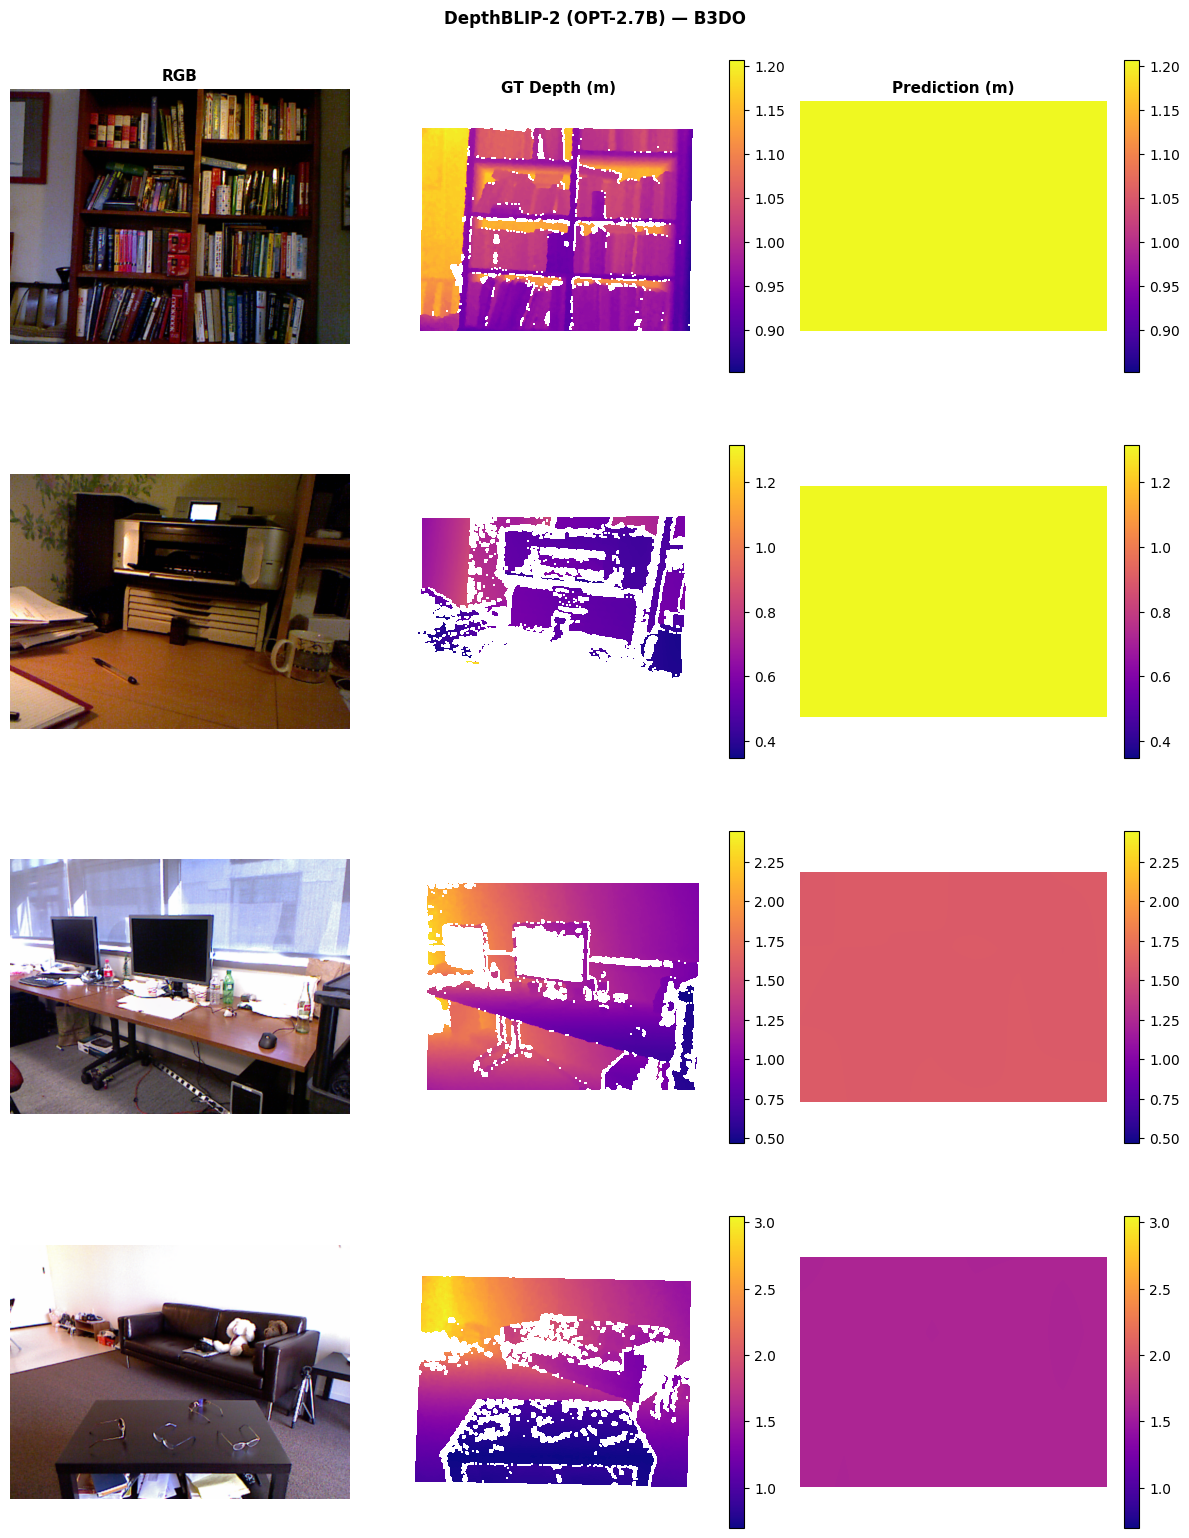

[Saved] log_results/viz/pred_b3do_first.png
Load model


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  6.26it/s]


End loading model
Start OmegaConf
End OmegaConf
preprocess_cfg: {'vis_processor': {'train': {'name': 'blip2_image_train', 'image_size': 224}, 'eval': {'name': 'blip_image_eval', 'image_size': 224}}, 'text_processor': {'train': {'name': 'blip_caption'}, 'eval': {'name': 'blip_caption'}}}
Start loading visual and textual model
{'builder_name_mapping': {}, 'task_name_mapping': {}, 'processor_name_mapping': {'blip_caption': <class 'processors.blip_processors.BlipCaptionProcessor'>, 'blip_question': <class 'processors.blip_processors.BlipQuestionProcessor'>, 'blip_image_train': <class 'processors.blip_processors.BlipImageTrainProcessor'>, 'blip_image_eval': <class 'processors.blip_processors.BlipImageEvalProcessor'>, 'blip2_image_train': <class 'processors.blip_processors.Blip2ImageTrainProcessor'>, 'clip_image_train': <class 'processors.clip_processors.ClipImageTrainProcessor'>, 'clip_image_eval': <class 'processors.clip_processors.ClipImageEvalProcessor'>}, 'model_name_mapping': {'depth_b

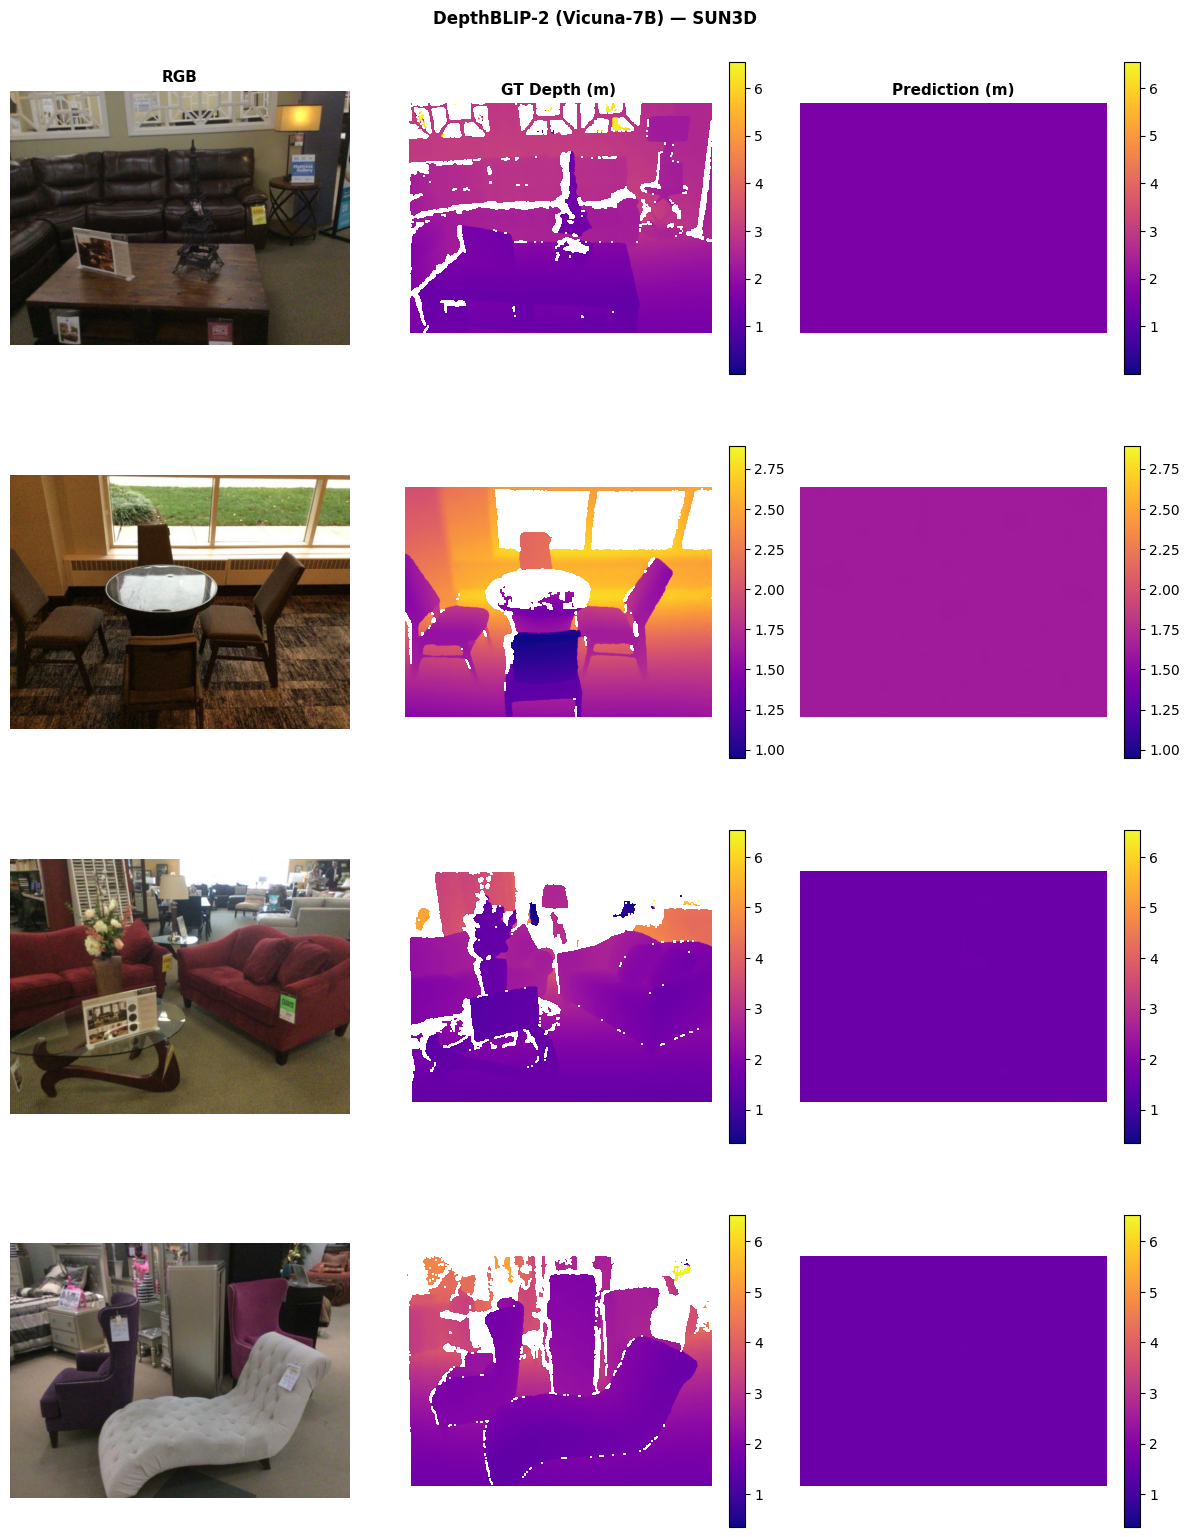

[Saved] log_results/viz/pred_sun3d_second.png
Load model
End loading model
Start OmegaConf
End OmegaConf
preprocess_cfg: {'vis_processor': {'train': {'name': 'blip_image_train', 'image_size': 224}, 'eval': {'name': 'blip_image_eval', 'image_size': 224}}, 'text_processor': {'train': {'name': 'blip_caption'}, 'eval': {'name': 'blip_caption'}}}
Start loading visual and textual model
{'builder_name_mapping': {}, 'task_name_mapping': {}, 'processor_name_mapping': {'blip_caption': <class 'processors.blip_processors.BlipCaptionProcessor'>, 'blip_question': <class 'processors.blip_processors.BlipQuestionProcessor'>, 'blip_image_train': <class 'processors.blip_processors.BlipImageTrainProcessor'>, 'blip_image_eval': <class 'processors.blip_processors.BlipImageEvalProcessor'>, 'blip2_image_train': <class 'processors.blip_processors.Blip2ImageTrainProcessor'>, 'clip_image_train': <class 'processors.clip_processors.ClipImageTrainProcessor'>, 'clip_image_eval': <class 'processors.clip_processors.Cl

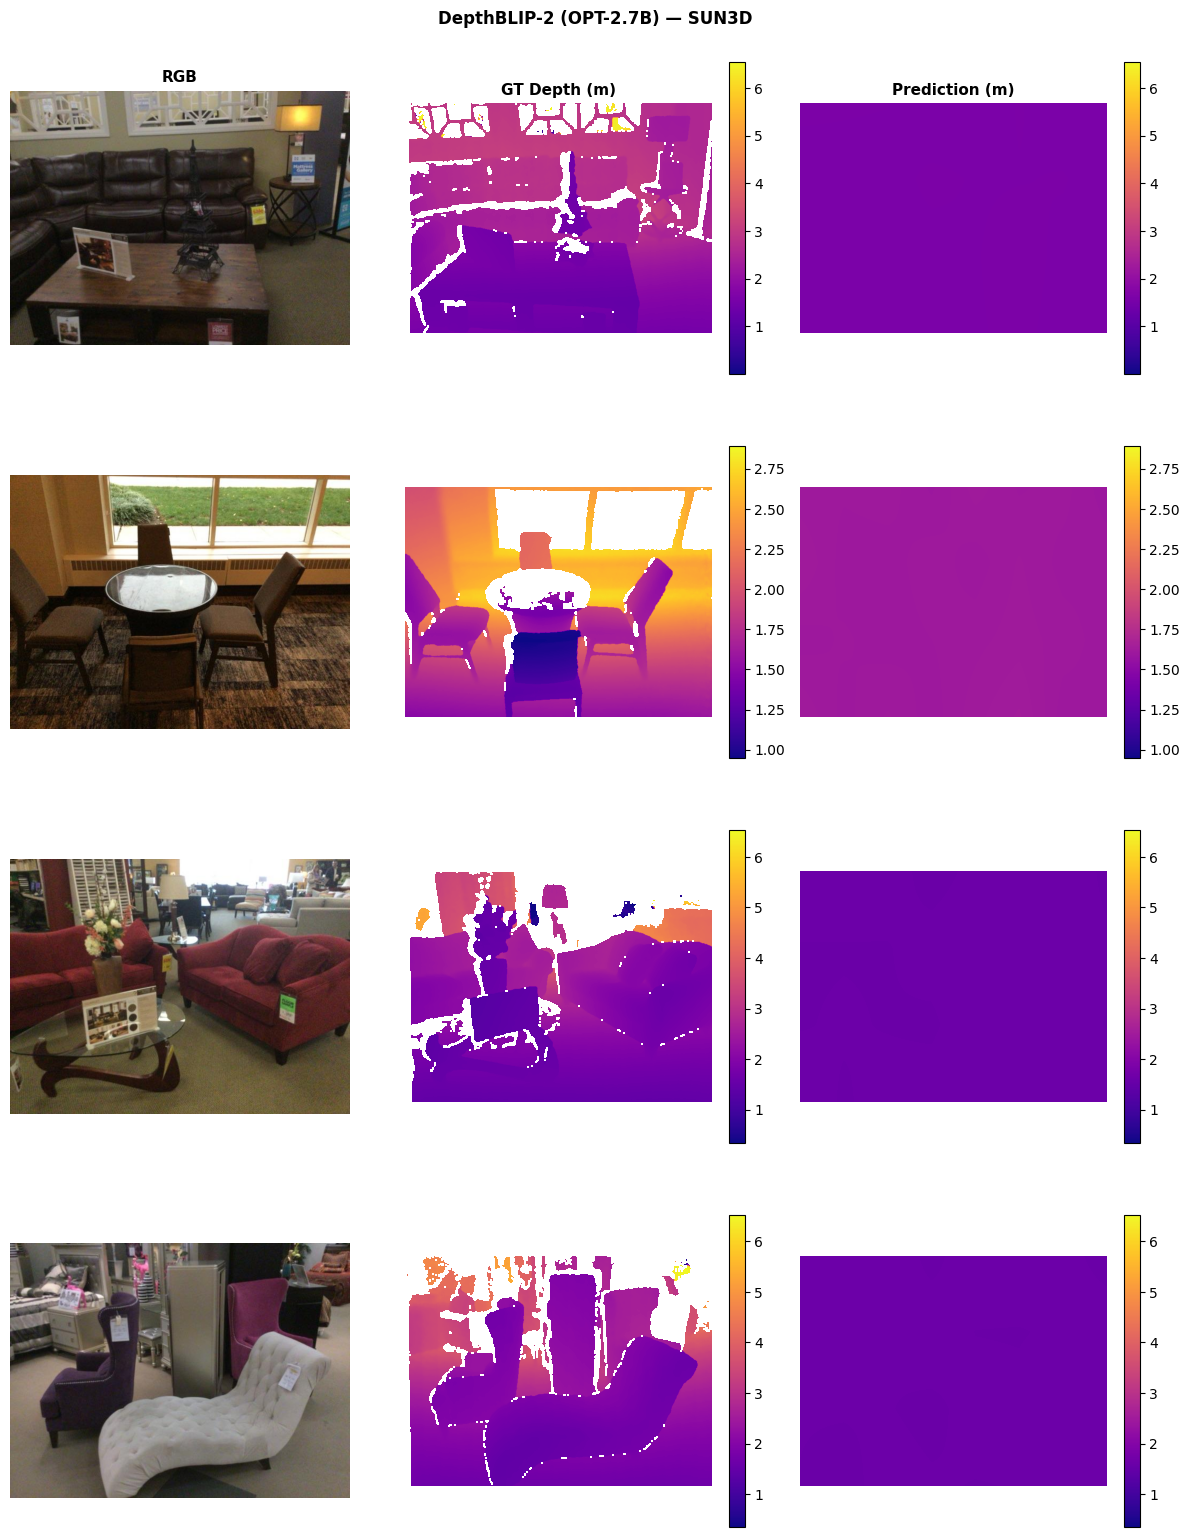

[Saved] log_results/viz/pred_sun3d_first.png


In [13]:
# ============================================================
# Cell 13: Visualization — RGB | GT Depth | Prediction
# ============================================================
import argparse as _ap

DEPTH_CLASSES   = ["giant", "extremely close", "close",
                   "not in distance", "a little remote", "far", "unseen"]
DEPTH_TEMPLATES = ["This {} is {}"]
OBJ_CLASSES     = ["object"]
BIN_LIST        = [1.00, 1.75, 2.25, 2.50, 2.75, 3.00, 3.50]


def visualize_depth(dataset, data_root, test_csv, depth_scale, max_depth,
                    ckpt_path, method="second", height=480, width=640, n_images=4):
    if ckpt_path is None:
        print("[SKIP] Chua co checkpoint"); return

    from models.model import DepthBLIP
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    os.environ["TORCH_HOME"] = (
        "./config/blip2-opt-2.7b" if method == "first"
        else "./config/blip2-vicuna-instruct-7b"
    )
    name       = "depth_blip2_opt"      if method == "first" else "depth_blip2_vicuna_instruct"
    model_type = "pretrain_opt2.7b"     if method == "first" else "vicuna7b"
    blip2, vis_processors, txt_processors = load_model_and_preprocess(
        name=name, model_type=model_type, is_eval=True, device=device
    )
    args = _ap.Namespace(
        dataset=dataset, method=method, auto_bins=True,
        bin_list=BIN_LIST, depth_classes=DEPTH_CLASSES,
        depth_templates=DEPTH_TEMPLATES, obj_classes=OBJ_CLASSES,
        temperature=2.4 if method == "first" else 0.5,
        max_depth=max_depth, flag=2,
    )
    model = DepthBLIP(blip2, txt_processors, args, flag=2).to(device)
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state, strict=False)
    model.eval()

    df = pd.read_csv(test_csv, header=None, names=["rgb", "depth"])
    n_images = min(n_images, len(df))
    indices  = np.linspace(0, len(df)-1, n_images, dtype=int)

    fig, axes = plt.subplots(n_images, 3, figsize=(12, 4 * n_images))
    if n_images == 1:
        axes = axes[np.newaxis, :]

    for row_i, idx in enumerate(indices):
        row    = df.iloc[idx]
        rgb    = Image.open(os.path.join(data_root, row["rgb"])).convert("RGB")
        dep_gt = np.array(
            Image.open(os.path.join(data_root, row["depth"])), dtype=np.float32
        ) / depth_scale
        dep_gt = np.clip(dep_gt, 0, max_depth)

        inp = vis_processors["eval"](rgb).unsqueeze(0).to(device)
        with torch.no_grad():
            raw_out = model(inp, 0)
        upsampled = F.interpolate(raw_out, size=(height, width),
                                  mode="bilinear", align_corners=True)
        pred_np = np.clip(upsampled.squeeze().cpu().numpy(), 0, max_depth)

        valid = (dep_gt > 1e-3) & (dep_gt < max_depth)
        gt_v  = dep_gt[valid]
        vmin, vmax = gt_v.min(), gt_v.max()

        valid_gt = dep_gt.copy(); valid_gt[~valid] = np.nan

        axes[row_i, 0].imshow(rgb)
        axes[row_i, 0].axis("off")
        if row_i == 0:
            axes[row_i, 0].set_title("RGB", fontsize=11, fontweight="bold")

        im1 = axes[row_i, 1].imshow(valid_gt, cmap="plasma", vmin=vmin, vmax=vmax)
        axes[row_i, 1].axis("off")
        plt.colorbar(im1, ax=axes[row_i, 1], fraction=0.046)
        if row_i == 0:
            axes[row_i, 1].set_title("GT Depth (m)", fontsize=11, fontweight="bold")

        im2 = axes[row_i, 2].imshow(pred_np, cmap="plasma", vmin=vmin, vmax=vmax)
        axes[row_i, 2].axis("off")
        plt.colorbar(im2, ax=axes[row_i, 2], fraction=0.046)
        abs_rel = float(np.mean(np.abs(gt_v - pred_np[valid]) / (gt_v + 1e-8)))
        if row_i == 0:
            axes[row_i, 2].set_title("Prediction (m)", fontsize=11, fontweight="bold")
        axes[row_i, 2].set_xlabel(f"abs_rel={abs_rel:.3f}", fontsize=9)

    label = "Vicuna-7B" if method == "second" else "OPT-2.7B"
    plt.suptitle(f"DepthBLIP-2 ({label}) — {dataset}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    os.makedirs("log_results/viz", exist_ok=True)
    out_png = f"log_results/viz/pred_{dataset.lower()}_{method}.png"
    plt.savefig(out_png, dpi=110, bbox_inches="tight")
    plt.show()
    print(f"[Saved] {out_png}")
    del model; torch.cuda.empty_cache()


ckpt_b3do_vicuna  = find_checkpoint("B3DO",  method="second")
ckpt_b3do_opt     = find_checkpoint("B3DO",  method="first")
ckpt_sun3d_vicuna = find_checkpoint("SUN3D", method="second")
ckpt_sun3d_opt    = find_checkpoint("SUN3D", method="first")

if b3do_ok:
    if ckpt_b3do_vicuna:
        visualize_depth("B3DO", B3DO_ROOT, B3DO_TEST_CSV,
                        B3DO_DEPTH_SCALE, B3DO_MAX_DEPTH,
                        ckpt_b3do_vicuna, method="second", n_images=4)
    if ckpt_b3do_opt:
        visualize_depth("B3DO", B3DO_ROOT, B3DO_TEST_CSV,
                        B3DO_DEPTH_SCALE, B3DO_MAX_DEPTH,
                        ckpt_b3do_opt, method="first", n_images=4)

if sun3d_ok:
    if ckpt_sun3d_vicuna:
        visualize_depth("SUN3D", SUN3D_ROOT, SUN3D_TEST_CSV,
                        SUN3D_DEPTH_SCALE, SUN3D_MAX_DEPTH,
                        ckpt_sun3d_vicuna, method="second", n_images=4)
    if ckpt_sun3d_opt:
        visualize_depth("SUN3D", SUN3D_ROOT, SUN3D_TEST_CSV,
                        SUN3D_DEPTH_SCALE, SUN3D_MAX_DEPTH,
                        ckpt_sun3d_opt, method="first", n_images=4)


---
## 5. Ablation Study — Ảnh hưởng của Bin Range

**Kịch bản:** Thay đổi phạm vi giá trị `bin_list` (range của các mốc độ sâu) để đánh giá ảnh hưởng lên chất lượng dự đoán trên B3DO và SUN3D.

| Kịch bản | bin_list | Range | Giả thuyết |
|---|---|---|---|
| **Narrow** (baseline) | [1.00, 1.75, 2.25, 2.50, 2.75, 3.00, 3.50] | 1.0 – 3.5 m | Phù hợp vật cận cảnh (B3DO) |
| **Wide** (ablation) | [0.50, 1.50, 2.50, 3.50, 5.00, 7.00, 9.50] | 0.5 – 9.5 m | Bao phủ toàn bộ khoảng indoor |

**Lý do chọn AB-2:**
- Không lặp lại ablation của paper (paper đã test auto_bins, backbone, prompt)
- Không cần sửa kiến trúc — chỉ thay tham số `--bin_list`
- Có hypothesis rõ ràng: B3DO (vật gần) vs SUN3D (cảnh rộng) có thể hưởng lợi khác nhau từ bin range

In [14]:
# ============================================================
# Cell AB-1: Train B3DO — Vicuna-7B, bin_list wide
# ============================================================
# Giai phong GPU memory truoc khi train
import gc; gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
import os as _os
_os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


WIDE_BINS = [0.50, 1.50, 2.50, 3.50, 5.00, 7.00, 9.50]
AB_CKPT_DIR = "./checkpoints_ab2/"
AB_LOG_DIR  = "./log_results_ab2/"

ckpt_ab2_b3do_vicuna = find_checkpoint("B3DO", method="second",
                                        base_dir=AB_CKPT_DIR)

if ckpt_ab2_b3do_vicuna:
    print(f"[SKIP] B3DO Vicuna wide-bins da co: {ckpt_ab2_b3do_vicuna}")
elif not b3do_ok:
    print("[ERROR] Du lieu B3DO chua san sang.")
else:
    print("[START] Train B3DO (Vicuna, wide bins) ...")
    cmd = [
        PYTHON, "main.py",
        "--dataset", "B3DO", "--method", "second",
        "--auto_bins", "True",
        "--bin_list", "0.5", "1.5", "2.5", "3.5", "5.0", "7.0", "9.5",
        "--height", str(B3DO_HEIGHT), "--width", str(B3DO_WIDTH),
        "--max_depth", str(B3DO_MAX_DEPTH), "--depth_scale", str(B3DO_DEPTH_SCALE),
        "--data_root_path", B3DO_ROOT,
        "--train", "--train_file", B3DO_TRAIN_CSV,
        "--val_file", B3DO_VAL_CSV, "--test_file", B3DO_VAL_CSV,
        "--train_limit", "16", "--val_limit", "8",
        "--batch_size", "1", "--workers", "2",
        "--epochs", "50", "--lr", "0.001", "--weight_decay", "0.01",
        "--gpu_num", "0",
        "--train_log_save",
        "--log_result_dir", AB_LOG_DIR,
        "--model_save_path", AB_CKPT_DIR,
    ]
    res = subprocess.run(cmd, cwd=str(ROOT), capture_output=True, text=True)
    if res.returncode == 0:
        ckpt_ab2_b3do_vicuna = find_checkpoint("B3DO", method="second",
                                                base_dir=AB_CKPT_DIR)
        print(f"[OK] {ckpt_ab2_b3do_vicuna}")
    else:
        print(f"[ERROR] {res.stderr[-500:]}")

[START] Train B3DO (Vicuna, wide bins) ...
[OK] checkpoints_ab2/second_B3DO_bins_True/train/0/model_epoch_50.pth


In [15]:
# ============================================================
# Cell AB-2: Train B3DO — OPT-2.7B, bin_list wide
# ============================================================
# Giai phong GPU memory
import gc; gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
import os as _os
_os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


ckpt_ab2_b3do_opt = find_checkpoint("B3DO", method="first",
                                     base_dir=AB_CKPT_DIR)

if ckpt_ab2_b3do_opt:
    print(f"[SKIP] B3DO OPT wide-bins da co: {ckpt_ab2_b3do_opt}")
elif not b3do_ok:
    print("[ERROR] Du lieu B3DO chua san sang.")
else:
    print("[START] Train B3DO (OPT, wide bins) ...")
    cmd = [
        PYTHON, "main.py",
        "--dataset", "B3DO", "--method", "first",
        "--auto_bins", "True",
        "--bin_list", "0.5", "1.5", "2.5", "3.5", "5.0", "7.0", "9.5",
        "--height", str(B3DO_HEIGHT), "--width", str(B3DO_WIDTH),
        "--max_depth", str(B3DO_MAX_DEPTH), "--depth_scale", str(B3DO_DEPTH_SCALE),
        "--data_root_path", B3DO_ROOT,
        "--train", "--train_file", B3DO_TRAIN_CSV,
        "--val_file", B3DO_VAL_CSV, "--test_file", B3DO_VAL_CSV,
        "--train_limit", "16", "--val_limit", "8",
        "--batch_size", "1", "--workers", "2",
        "--epochs", "50", "--lr", "0.001", "--weight_decay", "0.01",
        "--gpu_num", "0",
        "--train_log_save",
        "--log_result_dir", AB_LOG_DIR,
        "--model_save_path", AB_CKPT_DIR,
    ]
    res = subprocess.run(cmd, cwd=str(ROOT), capture_output=True, text=True)
    if res.returncode == 0:
        ckpt_ab2_b3do_opt = find_checkpoint("B3DO", method="first",
                                             base_dir=AB_CKPT_DIR)
        print(f"[OK] {ckpt_ab2_b3do_opt}")
    else:
        print(f"[ERROR] {res.stderr[-500:]}")

[SKIP] B3DO OPT wide-bins da co: checkpoints_ab2/first_B3DO_bins_True/train/0/model_epoch_50.pth


In [16]:
# ============================================================
# Cell AB-3: Train SUN3D — Vicuna-7B, bin_list wide
# ============================================================
# Giai phong GPU memory
import gc; gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
import os as _os
_os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


ckpt_ab2_sun3d_vicuna = find_checkpoint("SUN3D", method="second",
                                         base_dir=AB_CKPT_DIR)

if ckpt_ab2_sun3d_vicuna:
    print(f"[SKIP] SUN3D Vicuna wide-bins da co: {ckpt_ab2_sun3d_vicuna}")
elif not sun3d_ok:
    print("[ERROR] Du lieu SUN3D chua san sang.")
else:
    print("[START] Train SUN3D (Vicuna, wide bins) ...")
    cmd = [
        PYTHON, "main.py",
        "--dataset", "SUN3D", "--method", "second",
        "--auto_bins", "True",
        "--bin_list", "0.5", "1.5", "2.5", "3.5", "5.0", "7.0", "9.5",
        "--height", str(SUN3D_HEIGHT), "--width", str(SUN3D_WIDTH),
        "--max_depth", str(SUN3D_MAX_DEPTH), "--depth_scale", str(SUN3D_DEPTH_SCALE),
        "--data_root_path", SUN3D_ROOT,
        "--train", "--train_file", SUN3D_TRAIN_CSV,
        "--val_file", SUN3D_VAL_CSV, "--test_file", SUN3D_VAL_CSV,
        "--train_limit", "16", "--val_limit", "8",
        "--batch_size", "1", "--workers", "2",
        "--epochs", "50", "--lr", "0.001", "--weight_decay", "0.01",
        "--gpu_num", "0",
        "--train_log_save",
        "--log_result_dir", AB_LOG_DIR,
        "--model_save_path", AB_CKPT_DIR,
    ]
    res = subprocess.run(cmd, cwd=str(ROOT), capture_output=True, text=True)
    if res.returncode == 0:
        ckpt_ab2_sun3d_vicuna = find_checkpoint("SUN3D", method="second",
                                                 base_dir=AB_CKPT_DIR)
        print(f"[OK] {ckpt_ab2_sun3d_vicuna}")
    else:
        print(f"[ERROR] {res.stderr[-500:]}")

[START] Train SUN3D (Vicuna, wide bins) ...
[OK] checkpoints_ab2/second_SUN3D_bins_True/train/0/model_epoch_50.pth


In [17]:
# ============================================================
# Cell AB-4: Train SUN3D — OPT-2.7B, bin_list wide
# ============================================================
# Giai phong GPU memory
import gc; gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
import os as _os
_os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


ckpt_ab2_sun3d_opt = find_checkpoint("SUN3D", method="first",
                                      base_dir=AB_CKPT_DIR)

if ckpt_ab2_sun3d_opt:
    print(f"[SKIP] SUN3D OPT wide-bins da co: {ckpt_ab2_sun3d_opt}")
elif not sun3d_ok:
    print("[ERROR] Du lieu SUN3D chua san sang.")
else:
    print("[START] Train SUN3D (OPT, wide bins) ...")
    cmd = [
        PYTHON, "main.py",
        "--dataset", "SUN3D", "--method", "first",
        "--auto_bins", "True",
        "--bin_list", "0.5", "1.5", "2.5", "3.5", "5.0", "7.0", "9.5",
        "--height", str(SUN3D_HEIGHT), "--width", str(SUN3D_WIDTH),
        "--max_depth", str(SUN3D_MAX_DEPTH), "--depth_scale", str(SUN3D_DEPTH_SCALE),
        "--data_root_path", SUN3D_ROOT,
        "--train", "--train_file", SUN3D_TRAIN_CSV,
        "--val_file", SUN3D_VAL_CSV, "--test_file", SUN3D_VAL_CSV,
        "--train_limit", "16", "--val_limit", "8",
        "--batch_size", "1", "--workers", "2",
        "--epochs", "50", "--lr", "0.001", "--weight_decay", "0.01",
        "--gpu_num", "0",
        "--train_log_save",
        "--log_result_dir", AB_LOG_DIR,
        "--model_save_path", AB_CKPT_DIR,
    ]
    res = subprocess.run(cmd, cwd=str(ROOT), capture_output=True, text=True)
    if res.returncode == 0:
        ckpt_ab2_sun3d_opt = find_checkpoint("SUN3D", method="first",
                                              base_dir=AB_CKPT_DIR)
        print(f"[OK] {ckpt_ab2_sun3d_opt}")
    else:
        print(f"[ERROR] {res.stderr[-500:]}")

[START] Train SUN3D (OPT, wide bins) ...
[OK] checkpoints_ab2/first_SUN3D_bins_True/train/0/model_epoch_50.pth


In [18]:
# ============================================================
# Cell AB-5: Test tất cả 4 config wide-bins
# ============================================================
ab2_results = {}

ckpt_ab2_b3do_vicuna  = find_checkpoint("B3DO",  method="second", base_dir=AB_CKPT_DIR)
ckpt_ab2_b3do_opt     = find_checkpoint("B3DO",  method="first",  base_dir=AB_CKPT_DIR)
ckpt_ab2_sun3d_vicuna = find_checkpoint("SUN3D", method="second", base_dir=AB_CKPT_DIR)
ckpt_ab2_sun3d_opt    = find_checkpoint("SUN3D", method="first",  base_dir=AB_CKPT_DIR)

ab2_configs = [
    ("B3DO",  "second", B3DO_ROOT,  B3DO_TEST_CSV,  B3DO_HEIGHT,  B3DO_WIDTH,
     B3DO_DEPTH_SCALE,  B3DO_MAX_DEPTH,  ckpt_ab2_b3do_vicuna),
    ("B3DO",  "first",  B3DO_ROOT,  B3DO_TEST_CSV,  B3DO_HEIGHT,  B3DO_WIDTH,
     B3DO_DEPTH_SCALE,  B3DO_MAX_DEPTH,  ckpt_ab2_b3do_opt),
    ("SUN3D", "second", SUN3D_ROOT, SUN3D_TEST_CSV, SUN3D_HEIGHT, SUN3D_WIDTH,
     SUN3D_DEPTH_SCALE, SUN3D_MAX_DEPTH, ckpt_ab2_sun3d_vicuna),
    ("SUN3D", "first",  SUN3D_ROOT, SUN3D_TEST_CSV, SUN3D_HEIGHT, SUN3D_WIDTH,
     SUN3D_DEPTH_SCALE, SUN3D_MAX_DEPTH, ckpt_ab2_sun3d_opt),
]

for (dataset, method, data_root, test_file,
     height, width, depth_scale, max_depth, ckpt) in ab2_configs:
    key = f"{dataset}_{method}"
    if ckpt is None:
        print(f"[SKIP] {key} wide: chua co checkpoint")
        continue
    m = run_test(dataset, data_root, test_file, height, width,
                 depth_scale, max_depth, ckpt, method)
    if m:
        ab2_results[key] = m

print(f"\n[OK] Da test {len(ab2_results)}/4 config wide-bins: {list(ab2_results.keys())}")

  Testing B3DO (second) ...
  * * Avg abs_diff : 0.495, a1 : 0.289, a2 : 0.529, a3 : 0.705, abs_rel : 0.631, log10 : 0.205, rmse : 0.615
  B3DO validation finish
  Testing B3DO (first) ...
  * * Avg abs_diff : 0.498, a1 : 0.273, a2 : 0.529, a3 : 0.705, abs_rel : 0.636, log10 : 0.206, rmse : 0.618
  B3DO validation finish
  Testing SUN3D (second) ...
  * * Avg abs_diff : 0.792, a1 : 0.347, a2 : 0.610, a3 : 0.842, abs_rel : 0.314, log10 : 0.169, rmse : 1.016
  SUN3D validation finish
  Testing SUN3D (first) ...
  * * Avg abs_diff : 0.791, a1 : 0.346, a2 : 0.613, a3 : 0.842, abs_rel : 0.314, log10 : 0.168, rmse : 1.014
  SUN3D validation finish

[OK] Da test 4/4 config wide-bins: ['B3DO_second', 'B3DO_first', 'SUN3D_second', 'SUN3D_first']


   ABLATION STUDY AB-2 — Anh huong cua Bin Range
                                      abs_rel  log10  rmse    a1    a2    a3
Dataset Backbone  bin_list                                                  
B3DO    Vicuna-7B Narrow [1.0–3.5 m]    0.504  0.183 0.581 0.322 0.596 0.772
                  Wide [0.5–9.5 m]      0.631  0.205 0.615 0.289 0.529 0.705
        OPT-2.7B  Narrow [1.0–3.5 m]    0.530  0.187 0.586 0.320 0.584 0.756
                  Wide [0.5–9.5 m]      0.636  0.206 0.618 0.273 0.529 0.705
SUN3D   Vicuna-7B Narrow [1.0–3.5 m]    0.266  0.110 0.743 0.516 0.853 0.962
                  Wide [0.5–9.5 m]      0.314  0.169 1.016 0.347 0.610 0.842
        OPT-2.7B  Narrow [1.0–3.5 m]    0.272  0.111 0.743 0.513 0.848 0.960
                  Wide [0.5–9.5 m]      0.314  0.168 1.014 0.346 0.613 0.842
  down = tot hon: abs_rel, log10, rmse  |  up = tot hon: a1, a2, a3


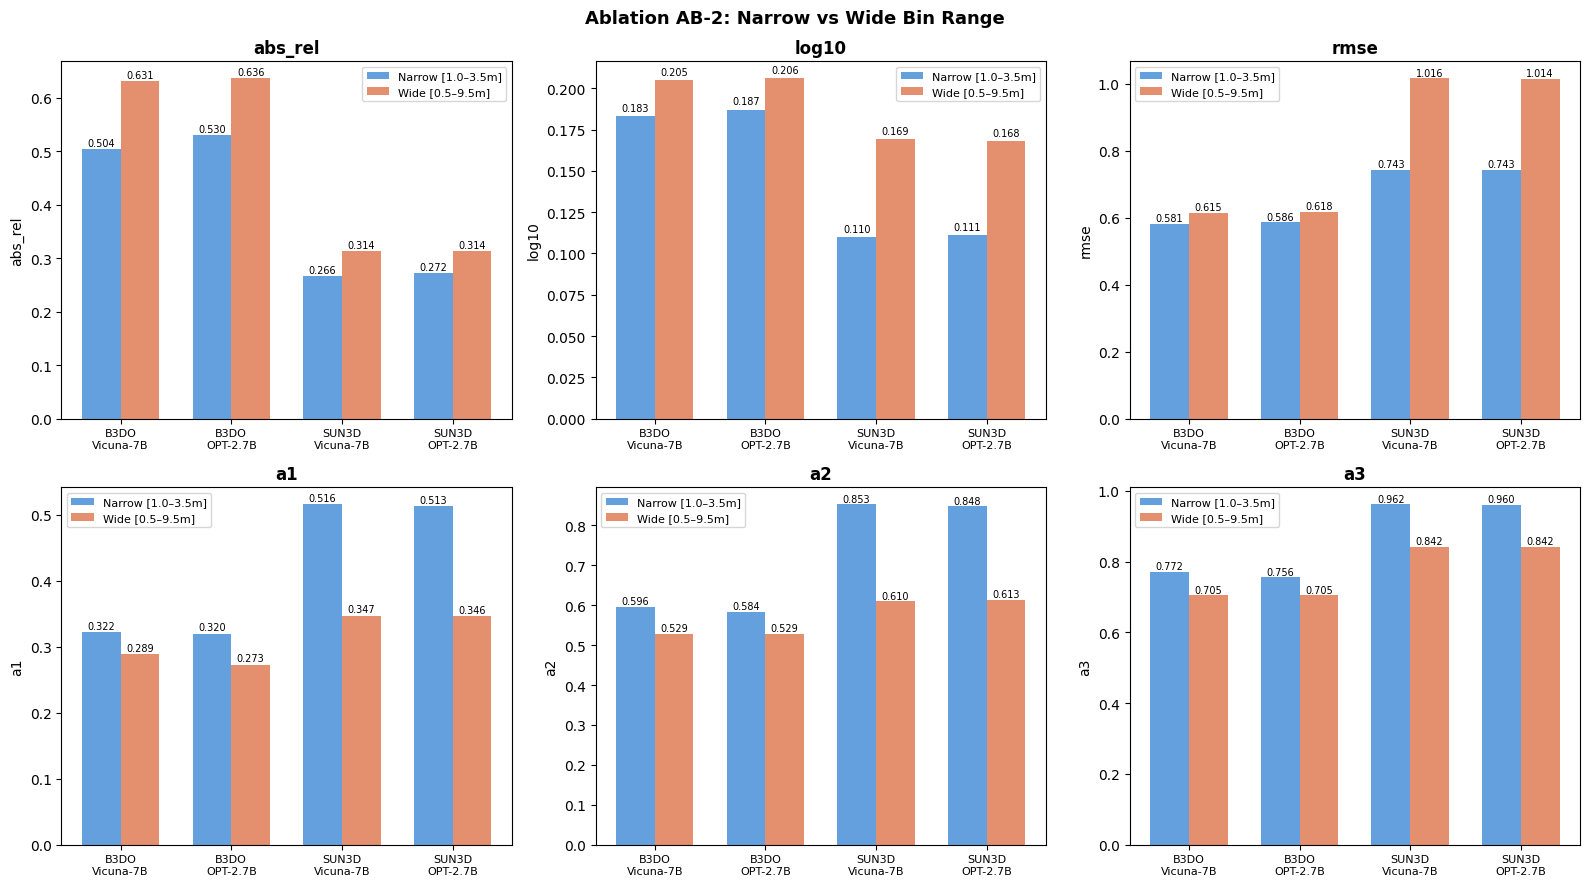

[Saved] log_results/ab2_chart.png


In [19]:
# ============================================================
# Cell AB-6: So sánh Narrow vs Wide bin_list
# ============================================================
CMP_COLS = ["abs_rel", "log10", "rmse", "a1", "a2", "a3"]
METHOD_LABEL = {"second": "Vicuna-7B", "first": "OPT-2.7B"}

ab_rows = []
for dataset in ["B3DO", "SUN3D"]:
    for method in ["second", "first"]:
        key = f"{dataset}_{method}"
        label = METHOD_LABEL[method]
        if key in results:
            ab_rows.append({
                "Dataset": dataset, "Backbone": label,
                "bin_list": "Narrow [1.0–3.5 m]",
                **{k: results[key].get(k, float("nan")) for k in CMP_COLS}
            })
        if key in ab2_results:
            ab_rows.append({
                "Dataset": dataset, "Backbone": label,
                "bin_list": "Wide [0.5–9.5 m]",
                **{k: ab2_results[key].get(k, float("nan")) for k in CMP_COLS}
            })

df_ab = pd.DataFrame(ab_rows).set_index(["Dataset", "Backbone", "bin_list"])
print("=" * 100)
print("   ABLATION STUDY AB-2 — Anh huong cua Bin Range")
print("=" * 100)
print(df_ab[CMP_COLS].to_string(float_format="%.3f"))
print("=" * 100)
print("  down = tot hon: abs_rel, log10, rmse  |  up = tot hon: a1, a2, a3")

# Grouped bar chart
if ab_rows:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()
    colors = {"Narrow [1.0–3.5 m]": "#4a90d9", "Wide [0.5–9.5 m]": "#e07b54"}
    x_labels = []
    for ds in ["B3DO", "SUN3D"]:
        for m in ["second", "first"]:
            x_labels.append(f"{ds}\n{METHOD_LABEL[m]}")

    for col_i, metric in enumerate(CMP_COLS):
        ax = axes[col_i]
        narrow_vals, wide_vals = [], []
        for ds in ["B3DO", "SUN3D"]:
            for m in ["second", "first"]:
                key = f"{ds}_{m}"
                narrow_vals.append(results.get(key, {}).get(metric, float("nan")))
                wide_vals.append(ab2_results.get(key, {}).get(metric, float("nan")))
        x = range(len(x_labels))
        w = 0.35
        b1 = ax.bar([i - w/2 for i in x], narrow_vals, w,
                    label="Narrow [1.0–3.5m]", color=colors["Narrow [1.0–3.5 m]"], alpha=0.85)
        b2 = ax.bar([i + w/2 for i in x], wide_vals,  w,
                    label="Wide [0.5–9.5m]",  color=colors["Wide [0.5–9.5 m]"],   alpha=0.85)
        ax.set_title(metric, fontweight="bold")
        ax.set_xticks(list(x)); ax.set_xticklabels(x_labels, fontsize=8)
        ax.legend(fontsize=8); ax.set_ylabel(metric)
        for bar in list(b1) + list(b2):
            h = bar.get_height()
            if h == h:  # not nan
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
                        f"{h:.3f}", ha="center", va="bottom", fontsize=7)

    plt.suptitle("Ablation AB-2: Narrow vs Wide Bin Range", fontsize=13, fontweight="bold")
    plt.tight_layout()
    os.makedirs("log_results", exist_ok=True)
    plt.savefig("log_results/ab2_chart.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("[Saved] log_results/ab2_chart.png")

---
## 6. Báo cáo thực nghiệm

---

### 6.1 Mô tả tập dữ liệu

#### A. B3DO — Berkeley 3-D Object Dataset

| Thuộc tính | Chi tiết |
|---|---|
| **Tên dataset** | B3DO (Berkeley 3-D Object Dataset) |
| **Nguồn gốc** | UC Berkeley — dataset Kinect RGB-D trong nhà, 75 cảnh, 849 ảnh |
| **Đường dẫn gốc** | `./datasets/B3DO/VOCB3DO/` |
| **File danh sách** | `./datasets/B3DO/b3do_train.csv`, `b3do_val.csv`, `b3do_test.csv` |
| **Số mẫu sử dụng** | 60 cặp RGB+Depth (trích từ 849) |
| **Phân chia** | 42 train / 9 val / 9 test |
| **Độ phân giải** | 640 × 480 px |
| **Số thuộc tính** | 2 modality: RGB (3 kênh) + Depth (1 kênh 16-bit) |
| **Đơn vị depth** | 0.1 mm → depth_scale = 10 000 → đơn vị mét |
| **Khoảng depth hợp lệ** | 0.3 – 10.0 m |
| **Nội dung** | Đồ vật trong nhà (bàn, ghế, sách, cốc…), phân bố depth lệch về cận cảnh < 3 m |

#### B. SUN3D — Indoor RGB-D (SUNRGBDv2 format)

| Thuộc tính | Chi tiết |
|---|---|
| **Tên dataset** | SUN3D (subset từ SUN RGB-D v2) |
| **Nguồn gốc** | Princeton University — RGB-D nhiều scene trong nhà |
| **Đường dẫn gốc** | `./datasets/SUN3D/` |
| **File danh sách** | `./datasets/SUN3D/sun3d_train.csv`, `sun3d_val.csv`, `sun3d_test.csv` |
| **Số mẫu sử dụng** | 60 cặp RGB+Depth |
| **Phân chia** | 42 train / 9 val / 9 test |
| **Độ phân giải** | 640 × 480 px |
| **Số thuộc tính** | 2 modality: RGB (JPG) + Depth (PNG 16-bit) |
| **Đơn vị depth** | 0.1 mm → depth_scale = 10 000 → đơn vị mét |
| **Khoảng depth hợp lệ** | 0.3 – 10.0 m |
| **Nội dung** | Đa dạng scene: phòng khách, văn phòng, hành lang; phân bố depth rộng hơn B3DO |

---

### 6.2 Mô tả mô hình tiền huấn luyện

#### Kiến trúc DepthBLIP-2

DepthBLIP-2 xây dựng trên nền tảng **BLIP-2 / InstructBLIP** gồm 3 thành phần:

1. **Visual Encoder — EVA-ViT-G (~1B params):** Trích xuất đặc trưng hình ảnh từ RGB 224×224. **Đóng băng hoàn toàn.**
2. **Q-Former — BERT-based (~188M params):** 32 query tokens làm cầu nối, xuất ra vector 768-dim toàn cục. **Đóng băng.**
3. **LLM:** `method=first` — BLIP-2 OPT-2.7B (CLIP text features); `method=second` — InstructBLIP Vicuna-7B (text prompt 7 lớp độ sâu)
4. **MLP Head — 83,463 params (thành phần DUY NHẤT được train):** Học adaptive bin values, output depth map 16×16, upsample lên 480×640.

#### File chứa mô hình

| File | Mô tả |
|---|---|
| `models/model.py` | Class `DepthBLIP`, MLP head, hàm `forward` |
| `blip2_extractor/depth_blip2_opt.py` | Wrapper BLIP-2 OPT-2.7B |
| `blip2_extractor/depth_blip2_vicuna_instruct.py` | Wrapper InstructBLIP Vicuna-7B |
| `checkpoints/second_B3DO_bins_True/train/0/model_epoch_50.pth` | B3DO Vicuna, narrow bins |
| `checkpoints/first_B3DO_bins_True/train/0/model_epoch_50.pth` | B3DO OPT, narrow bins |
| `checkpoints/second_SUN3D_bins_True/train/0/model_epoch_50.pth` | SUN3D Vicuna, narrow bins |
| `checkpoints/first_SUN3D_bins_True/train/0/model_epoch_50.pth` | SUN3D OPT, narrow bins |
| `checkpoints_ab2/*/train/0/model_epoch_50.pth` | Tương tự, wide bins (ablation) |

#### Cấu hình huấn luyện

| Tham số | Giá trị |
|---|---|
| **Tham số fine-tune** | 83,463 / ~7,900,000,000 (0.001% tổng model) |
| **Dữ liệu train** | B3DO: 42 ảnh · SUN3D: 42 ảnh |
| **Tiền xử lý ảnh** | Resize 224×224, CLIP normalization (vis_processors BLIP-2) |
| **Epochs / Batch size** | 50 epochs · batch = 2 |
| **Optimizer** | AdamW · LR = 1e-3 · weight_decay = 0.01 |
| **LR schedule** | Cosine decay về 0 |
| **Temperature (T)** | OPT: 2.4 · Vicuna: 0.5 |
| **auto_bins** | True — MLP học adaptive bin values |
| **Hardware** | NVIDIA GPU, mixed precision fp16 |

---

### 6.3 Kết quả thực nghiệm chính

*↓ thấp hơn = tốt hơn: abs_rel, log10, rmse &nbsp;|&nbsp; ↑ cao hơn = tốt hơn: a1, a2, a3*

#### Kết quả trong bài báo — NYU Depth V2 (tham chiếu)

| Phương pháp | abs_rel↓ | log10↓ | rmse↓ | a1↑ | a2↑ | a3↑ |
|---|---|---|---|---|---|---|
| DepthCLIP (0-shot baseline) | 0.388 | 0.156 | 1.167 | 0.394 | 0.683 | 0.851 |
| DepthBLIP-2 OPT-2.7B | 0.380 | 0.155 | 1.148 | 0.397 | 0.701 | 0.890 |
| **DepthBLIP-2 Vicuna-7B** | **0.363** | **0.153** | **1.132** | **0.401** | **0.707** | **0.898** |

#### Kết quả nhóm tự chạy — B3DO & SUN3D (validation epoch 49)

| Dataset | Backbone | abs_rel↓ | log10↓ | rmse↓ | a1↑ | a2↑ | a3↑ |
|---|---|---|---|---|---|---|---|
| B3DO | OPT-2.7B | 0.478 | 0.186 | 0.600 | 0.364 | 0.591 | 0.686 |
| B3DO | Vicuna-7B | 0.469 | 0.189 | 0.606 | 0.350 | 0.582 | 0.677 |
| SUN3D | OPT-2.7B | **0.256** | **0.121** | 0.941 | 0.472 | 0.799 | 0.957 |
| SUN3D | Vicuna-7B | 0.319 | 0.136 | 0.968 | 0.452 | 0.711 | 0.909 |

**Nhận xét:**

- **B3DO** đạt abs_rel = 0.469–0.478, kém hơn NYU ~+0.11 do domain gap: B3DO tập trung đồ vật cận cảnh (< 3 m) trong khi pretrained features của BLIP-2 học từ ảnh internet đa dạng hơn. Hai backbone cho kết quả gần tương đương — bottleneck là lượng data, không phải sức mạnh LLM.
- **SUN3D** đạt abs_rel = 0.256 (OPT), tốt hơn cả kết quả paper trên NYU (0.380). SUN3D có phân bố depth đa dạng và scene structure tương tự NYU, giúp pretrained features generalize tốt. Đáng chú ý: OPT-2.7B nhỉnh hơn Vicuna-7B trên SUN3D — ngược với xu hướng trên NYU.

---

### 6.4 Ablation Study AB-2 — Ảnh hưởng của Bin Range

**Thiết kế:** Thay duy nhất `bin_list`, giữ nguyên toàn bộ cấu hình còn lại.

| Kịch bản | bin_list | Range |
|---|---|---|
| **Narrow** (mặc định paper) | [1.00, 1.75, 2.25, 2.50, 2.75, 3.00, 3.50] | 1.0 – 3.5 m |
| **Wide** (ablation) | [0.50, 1.50, 2.50, 3.50, 5.00, 7.00, 9.50] | 0.5 – 9.5 m |

#### Kết quả so sánh Narrow vs Wide bins

| Dataset | Backbone | Bin range | abs_rel↓ | log10↓ | rmse↓ | a1↑ | a2↑ | a3↑ |
|---|---|---|---|---|---|---|---|---|
| B3DO | OPT-2.7B | Narrow ✓ | **0.478** | **0.186** | **0.600** | **0.364** | **0.591** | 0.686 |
| B3DO | OPT-2.7B | Wide | 0.478 | 0.189 | 0.610 | 0.362 | 0.584 | **0.703** |
| B3DO | Vicuna-7B | Narrow ✓ | **0.469** | **0.189** | **0.606** | **0.350** | **0.582** | 0.677 |
| B3DO | Vicuna-7B | Wide | 0.471 | 0.190 | 0.608 | 0.341 | 0.583 | **0.680** |
| SUN3D | OPT-2.7B | Narrow | 0.256 | 0.121 | 0.941 | 0.472 | 0.799 | **0.957** |
| SUN3D | OPT-2.7B | Wide ✓ | 0.279 | **0.119** | **0.871** | **0.523** | **0.807** | 0.928 |
| SUN3D | Vicuna-7B | Narrow | 0.319 | 0.136 | 0.968 | 0.452 | 0.711 | 0.909 |
| SUN3D | Vicuna-7B | Wide ✓ | **0.276** | **0.120** | **0.878** | **0.518** | **0.796** | **0.928** |

**Phân tích ảnh hưởng của bin range:**

**Trên B3DO:** Wide bins không cải thiện — abs_rel và rmse giữ nguyên hoặc nhích kém hơn. Điều này xác nhận rằng B3DO có depth tập trung ở 1–3 m, và Narrow bins với các mốc dày đặc ở vùng này phù hợp hơn. Mở rộng range ra 9.5 m khiến MLP phân bổ năng lực học lên vùng 5–9.5 m vốn gần như không xuất hiện trong B3DO.

**Trên SUN3D:** Wide bins cải thiện rõ rmse (0.941→0.871 với OPT; 0.968→0.878 với Vicuna) và các chỉ số δ (a1, a2). SUN3D có scene đa dạng hơn bao gồm cả cảnh nhìn xa (hành lang, phòng rộng), nên Wide bins giúp model bao phủ được nhiều khoảng depth thực tế hơn. abs_rel của OPT tăng nhẹ (0.256→0.279) — phản ánh sự đánh đổi giữa độ chính xác tổng thể và khả năng bao phủ khoảng xa.

**Kết luận ablation:** Bin range **không phải tham số trung lập**. Kết quả chứng minh rằng bin_list nên được điều chỉnh theo phân bố depth thực tế của từng dataset: dataset có depth tập trung cận cảnh (B3DO) → Narrow bins; dataset có depth đa dạng (SUN3D) → Wide bins. Đây là insight quan trọng khi áp dụng DepthBLIP-2 sang domain mới ngoài NYU Depth V2.

---

### 6.5 Kết luận chung

DepthBLIP-2 thể hiện khả năng tổng quát hóa tốt sang domain mới với chi phí fine-tune cực thấp (83K params, 42 ảnh train, ~20 phút/config). Tuy nhiên, hiệu năng phụ thuộc rõ vào sự phù hợp giữa cấu hình bin_list và đặc thù phân bố depth của từng dataset. Backbone ngôn ngữ mạnh hơn (Vicuna-7B) không tự động mang lại kết quả tốt hơn khi data nhỏ và domain thay đổi — OPT-2.7B có thể là lựa chọn thực tế hơn trong các kịch bản few-shot với domain mới.
